In [1]:
import numpy as np
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from operator import truediv
from ultralytics import YOLO
import itertools
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
#import splitfolders 
# https://www.youtube.com/watch?v=vuOB6oiV0IM&ab_channel=PythonProgramming - Make string bold
%matplotlib inline

## ACTIVATE GPU

In [2]:
# Check for CUDA device and set it
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}') 

Using device: cuda


## DEFINE THE FUNCTIONS NEEDED FOR TEST DATASETS

In [3]:
def get_test_images_full_path(test_data_dir):
    print("Get the images from test directory for prediction")
    base_dir = test_data_dir
    # Initialize an empty dictionary to store file paths and folder names
    file_folder_dict = {}
    
    # Recursively traverse through each subdirectory
    for root, dirs, files in os.walk(base_dir):
        # Extract the folder name from the current directory
        folder_name = os.path.basename(root)
        # Iterate through each file in the current directory
        for file in files:
            # Construct the full path to the file
            file_path = os.path.join(root, file)
            # Add file path and folder name to the dictionary
            file_folder_dict[file_path] = folder_name
    
    actual_image = []
    predicted_image = [] 
    for i, folder_name in file_folder_dict.items():
        results = model(i) 
        
        names_dict = results[0].names
        probs = results[0].probs.data.tolist()
        
        print(names_dict)
        print(probs)
        
        prediction = names_dict[np.argmax(probs)]
    
        actual_image.append(folder_name)
        predicted_image.append(prediction)
        
        print(names_dict[np.argmax(probs)])

    print("Actual and Predicted Images list ready for Prediction")
    print('-------------------------------------------------------------------------------------------------------------------------------')
    print('\n')

    return actual_image, predicted_image
    

def con_matrix_test(actual_image, predicted_image ):
    """
    This function plots the confusion matrix for the yolo test dataset.

    :param actual_image: The class of the actual images from test directory
    :param predicted_image: The class of the actual images from test directory
    
    :return: print the confusion matrix and return the variable 'confusion matrix'.
    
    """
    print("Plot Confusion Matrix")
    # Get unique predicted labels
    classes = sorted(list(set(actual_image)))

    # Create confusion matrix
    conf_matrix = confusion_matrix(actual_image, predicted_image, labels=classes)
    
    print("Confusion Matrix:")
    # Plot confusion matrix
    plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    
    fmt = 'd'
    thresh = conf_matrix.max() / 2.
    for i, j in itertools.product(range(conf_matrix.shape[0]), range(conf_matrix.shape[1])):
        plt.text(j, i, format(conf_matrix[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if conf_matrix[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

    # Classification Report
    report = classification_report(actual_image, predicted_image, labels=classes)

    # Accuracy
    acc_score = accuracy_score(actual_image, predicted_image)

    # Precision, Recall, F1-score
    precision = precision_score(actual_image, predicted_image, average='weighted')
    recall = recall_score(actual_image, predicted_image, average='weighted')
    f1 = f1_score(actual_image, predicted_image, average='weighted')

    print("Accuracy Score:", acc_score)
    print("Precision Score:", precision)
    print("Recall Score:", recall)
    print("F1 Score:", f1)
    print("Classification Report:")
    print(report)

    print("Confusion Matrix Plotted and ready for metrics evaluation")
    print('-------------------------------------------------------------------------------------------------------------------------------')
    print('\n')
    return conf_matrix

def metrics_test(conf_matrix , yolo_val_metrics = True):
    """
    This function gets the metrics for the yolo test dataset.

    :param conf_matrix: Gets the confusion matrix from the conf_matrix_test function
    
    :return: prints the metrics scores for the yolo test datasets'.
    
    """
    print('-------------------------------------------------------------------------------------------------------------------------------')
    print('\n')

    global results_path
    df = pd.read_csv(results_path)
    

    # Get the last value of the 'test_accuracy' column
    last_accuracy = df['metrics/accuracy_top1'].iloc[-1]
    global name_model
    global results
    
    if not yolo_val_metrics:
        # Extracting TP, TN, FP, FN
        TP = np.diag(conf_matrix)
        FP = np.sum(conf_matrix, axis=0) - TP
        FN = np.sum(conf_matrix, axis=1) - TP
        TN = np.sum(conf_matrix) - (TP + FP + FN)
        
        # Calculate Accuracy, Precision, and Recall
        accuracy = np.sum(TP) / np.sum(TP + FN)
        precision = np.mean(TP / (TP + FP))
        recall = np.mean(TP / (TP + FN))

    else:
        conf_matrix = np.array(conf_matrix)
        TP = np.diag(conf_matrix)
        FP = np.sum(conf_matrix, axis=0) - TP
        FN = np.sum(conf_matrix, axis=1) - TP
        precision = np.mean(TP / (TP + FP))
        recall = np.mean(TP / (TP + FN))
        
        accuracy = np.sum(TP) / np.sum(conf_matrix)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)

    # \save the variables in the empty list
    results.append({'name_model': name_model,'Train Accuracy': last_accuracy, 'Val Accuracy': last_accuracy,'Test Accuracy': accuracy, 'Precision': precision,'Recall': recall})

    print('-------------------------------------------------------------------------------------------------------------------------------')
    print('\n')

In [4]:
def yolo_model_plot(results_path):
    results = pd.read_csv(results_path)

    plt.figure()
    plt.plot(results['epoch'], results['train/loss'], label='train loss')
    plt.plot(results['epoch'], results['val/loss'], label='val loss', c='red')
    plt.grid()
    plt.title('Loss vs epochs')
    plt.ylabel('loss')
    plt.xlabel('epochs')
    plt.legend()
    
    
    plt.figure()
    plt.plot(results['epoch'], results['metrics/accuracy_top1'] * 100)
    plt.grid()
    plt.title('Validation accuracy vs epochs')
    plt.ylabel('accuracy (%)')
    plt.xlabel('epochs')
    
    plt.show()
    
    final_results = results[['epoch', 'train/loss','val/loss', 'metrics/accuracy_top1']]
    final_results

# Multi Cells CLASSIFICATION WITHOUT AUGMENTATION

In [5]:
results = []

Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: task=classify, mode=train, model=yolo11n-cls.pt, data=C:\Users\conso\Desktop\qq\Mcells\Completed_2, epochs=30, time=None, patience=100, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=Fal

train: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_2\train... 1100 images, 0 corrupt: 100%|██████████| 1100/110
val: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_2\val... 314 images, 0 corrupt: 100%|██████████| 314/314 [00:0


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\train
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 38.85it/s]

                   all      0.411          1


...

      30/30     0.281G     0.6079         12        224: 100%|██████████| 69/69 [00:03<00:00, 21.33it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 68.48it/s]

                   all      0.764          1



30 epochs completed in 0.039 hours.
Optimizer stripped from runs\classify\train\weights\last.pt, 3.2MB
Optimizer stripped from runs\classify\train\weights\best.pt, 3.2MB

Validating runs\classify\train\weights\best.pt...
Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n-cls summary (fused): 112 layers, 1,531,148 parameters, 0 gradients, 3.2 GFLOPs
train: C:\Users\conso\Desktop\qq\Mcells\Completed_2\train... found 1100 images in 4 classes  
val: C:\Users\conso\Desktop\qq\Mcells\Completed_2\val... found 314 images in 4 classes  
test: C:\Users\conso\Desktop\qq\Mcells\Completed_2\test... found 161 images in 4 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 49.03it/s]


                   all      0.771          1
Speed: 0.1ms preprocess, 0.5ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train
-------------------------------
 Yolov11 N


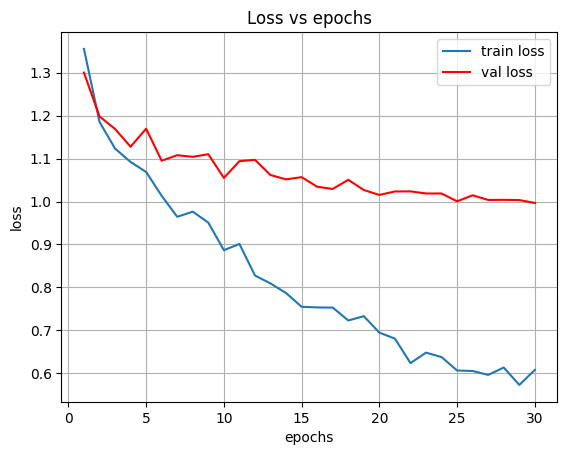

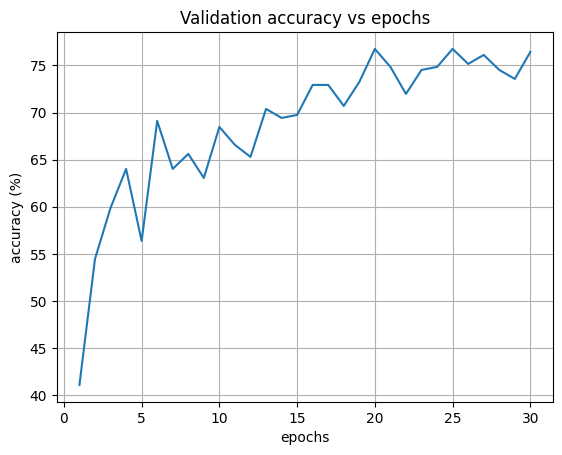

Load Best Model
Get the images from test directory for prediction

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 15.03.22 -02_1_0.jpg: 224x224 Zinc 0.56, Milrinone+zinc 0.30, Control 0.13, Milrinone 0.01, 15.7ms
Speed: 0.0ms preprocess, 15.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.12981954216957092, 0.008997409604489803, 0.3032335042953491, 0.5579495429992676]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 15.03.22 -03_1_0.jpg: 224x224 Control 0.78, Zinc 0.20, Milrinone+zinc 0.02, Milrinone 0.00, 33.0ms
Speed: 5.7ms preprocess, 33.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.779638946056366, 0.00017915993521455675, 0.015919754281640053, 0.2042621523141861]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Co

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999783039093018, 1.117740339395823e-06, 5.468582386924936e-08, 2.0626213881769218e-05]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.05.22 D004-02_1_2.jpg: 224x224 Control 0.87, Milrinone+zinc 0.07, Zinc 0.06, Milrinone 0.00, 7.9ms
Speed: 5.0ms preprocess, 7.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8686957359313965, 0.00429977523162961, 0.06809832900762558, 0.058906249701976776]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.05.22 D004-02_2_1.jpg: 224x224 Control 0.67, Milrinone 0.30, Milrinone+zinc 0.03, Zinc 0.00, 8.6ms
Speed: 3.2ms preprocess, 8.6ms inference, 2.9ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.6742256283760071, 0.29661378264427185, 0.028003660

Speed: 5.0ms preprocess, 10.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9026236534118652, 0.006745101418346167, 0.08667659759521484, 0.0039546252228319645]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22_0_1.jpg: 224x224 Zinc 0.94, Milrinone 0.03, Control 0.02, Milrinone+zinc 0.01, 10.9ms
Speed: 4.6ms preprocess, 10.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.024159129709005356, 0.030192960053682327, 0.008631727658212185, 0.9370161294937134]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100  10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone+zinc 0.67, Control 0.20, Milrinone 0.09, Zinc 0.03, 10.4ms
Speed: 3.8ms preprocess, 10.4ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: '

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_0_2.jpg: 224x224 Zinc 0.64, Milrinone 0.24, Control 0.12, Milrinone+zinc 0.01, 11.4ms
Speed: 3.4ms preprocess, 11.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.12080618739128113, 0.23745161294937134, 0.006480211857706308, 0.6352619528770447]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_2_2.jpg: 224x224 Zinc 0.54, Control 0.20, Milrinone 0.16, Milrinone+zinc 0.10, 10.5ms
Speed: 4.0ms preprocess, 10.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.19537554681301117, 0.1615663319826126, 0.10399274528026581, 0.539065420627594]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 Milrinone 25.05.22 D004-03_1_2.jpg: 224

Speed: 4.8ms preprocess, 11.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[8.170002547558397e-05, 0.9991518259048462, 0.0007382759940810502, 2.8169255529064685e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_2_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 10.5ms
Speed: 4.6ms preprocess, 10.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00040295152575708926, 0.9982410669326782, 0.0013404232449829578, 1.560229793540202e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100  Zinc+ 10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Zinc 0.00, Milrinone 0.00, 12.8ms
Speed: 2.2ms preprocess, 12.8ms inference, 0.0ms postprocess per image at shap

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_2_0.jpg: 224x224 Milrinone+zinc 0.95, Control 0.04, Milrinone 0.00, Zinc 0.00, 10.6ms
Speed: 4.0ms preprocess, 10.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.04349341243505478, 0.0022405460476875305, 0.9537362456321716, 0.0005298182950355113]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-05_0_2.jpg: 224x224 Milrinone+zinc 0.99, Zinc 0.01, Milrinone 0.00, Control 0.00, 11.3ms
Speed: 4.1ms preprocess, 11.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.5877321604639292e-05, 0.0001339894370175898, 0.9864698052406311, 0.013370325788855553]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milr

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.01974702998995781, 0.004466688726097345, 0.024913480505347252, 0.9508728384971619]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_0.jpg: 224x224 Milrinone+zinc 0.99, Milrinone 0.01, Zinc 0.00, Control 0.00, 10.4ms
Speed: 6.7ms preprocess, 10.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0002561145811341703, 0.009671011008322239, 0.9854040741920471, 0.004668785724788904]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_2.jpg: 224x224 Milrinone+zinc 0.54, Zinc 0.25, Control 0.15, Milrinone 0.05, 12.6ms
Speed: 1.8ms preprocess, 12.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -03_1_0.jpg: 224x224 Zinc 0.98, Milrinone 0.01, Control 0.00, Milrinone+zinc 0.00, 6.9ms
Speed: 4.3ms preprocess, 6.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.004916950594633818, 0.012458198703825474, 0.0004016367602162063, 0.9822232723236084]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -04_2_2.jpg: 224x224 Milrinone 0.39, Milrinone+zinc 0.31, Zinc 0.30, Control 0.01, 9.0ms
Speed: 3.7ms preprocess, 9.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.013180289417505264, 0.3860156238079071, 0.3055642545223236, 0.2952398955821991]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 _0_0.jpg: 224x224 Milrinone+zinc 0.79

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.6854828572832048e-05, 0.007450342644006014, 0.959194540977478, 0.03333831951022148]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_2.jpg: 224x224 Zinc 0.78, Milrinone+zinc 0.22, Milrinone 0.00, Control 0.00, 9.7ms
Speed: 3.5ms preprocess, 9.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.0040622555607115e-06, 0.0001624860888114199, 0.22225415706634521, 0.7775823473930359]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21_0_2.jpg: 224x224 Zinc 0.53, Milrinone+zinc 0.28, Milrinone 0.16, Control 0.03, 10.0ms
Speed: 4.8ms preprocess, 10.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.027568040415644646, 0.1579933911561966, 0.28454717993736267, 0.529891

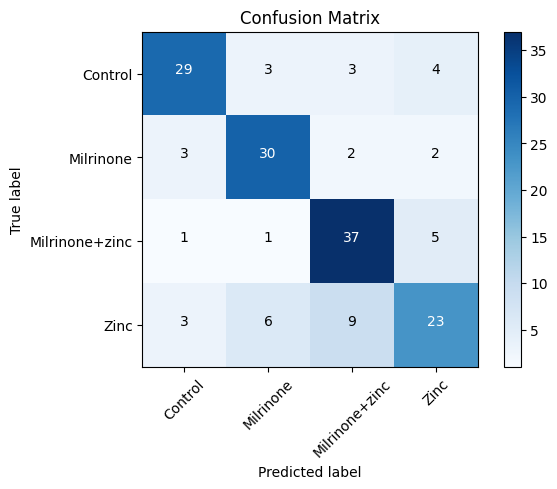

Accuracy Score: 0.7391304347826086
Precision Score: 0.7380343441724516
Recall Score: 0.7391304347826086
F1 Score: 0.7354752776916883
Classification Report:
                precision    recall  f1-score   support

       Control       0.81      0.74      0.77        39
     Milrinone       0.75      0.81      0.78        37
Milrinone+zinc       0.73      0.84      0.78        44
          Zinc       0.68      0.56      0.61        41

      accuracy                           0.74       161
     macro avg       0.74      0.74      0.74       161
  weighted avg       0.74      0.74      0.74       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.7391304347826086
Precision: 0.7393790849673203
Recall: 0.739071

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-04_2_0.jpg: 224x224 Control 0.96, Zinc 0.02, Milrinone+zinc 0.01, Milrinone 0.01, 8.5ms
Speed: 5.2ms preprocess, 8.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.958997368812561, 0.00822171475738287, 0.01363972295075655, 0.019141262397170067]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-05_0_2.jpg: 224x224 Milrinone 0.74, Control 0.10, Zinc 0.10, Milrinone+zinc 0.07, 8.7ms
Speed: 5.1ms preprocess, 8.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.09887028485536575, 0.7362286448478699, 0.06956572830677032, 0.09533540904521942]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-05_2_2.jpg: 224x224 Cont

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-05_2_0.jpg: 224x224 Control 0.86, Milrinone+zinc 0.09, Zinc 0.05, Milrinone 0.00, 9.0ms
Speed: 5.1ms preprocess, 9.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8550520539283752, 0.0037392752710729837, 0.08927249908447266, 0.05193623900413513]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-07_1_2.jpg: 224x224 Control 0.80, Milrinone+zinc 0.17, Milrinone 0.03, Zinc 0.00, 10.2ms
Speed: 4.4ms preprocess, 10.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8031886219978333, 0.030344318598508835, 0.16534435749053955, 0.001122767454944551]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-07_2_2.jpg: 224x224 Control 0.89, Milr

Speed: 4.5ms preprocess, 9.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0004578717052936554, 0.9292439818382263, 0.05972300097346306, 0.010575064457952976]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_1.jpg: 224x224 Control 0.87, Zinc 0.06, Milrinone+zinc 0.05, Milrinone 0.02, 10.7ms
Speed: 4.8ms preprocess, 10.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8663970828056335, 0.022857261821627617, 0.051794666796922684, 0.05895105004310608]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_2_0.jpg: 224x224 Milrinone 0.75, Milrinone+zinc 0.20, Zinc 0.04, Control 0.00, 10.3ms
Speed: 4.4ms preprocess, 10.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.209659967571497e-05, 0.9999798536300659, 7.882396857894491e-06, 1.330176644387393e-07]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_2.jpg: 224x224 Milrinone 0.95, Control 0.04, Milrinone+zinc 0.01, Zinc 0.00, 9.8ms
Speed: 4.4ms preprocess, 9.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.04460040479898453, 0.9475828409194946, 0.007384125608950853, 0.00043263949919492006]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_1.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Zinc 0.00, Control 0.00, 9.7ms
Speed: 4.2ms preprocess, 9.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.7931535189272836e-05, 0.99869799613952

Speed: 5.0ms preprocess, 9.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[4.4502445234684274e-05, 6.606455281144008e-05, 0.8664863705635071, 0.13340306282043457]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_0.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Milrinone 0.00, Control 0.00, 9.3ms
Speed: 5.0ms preprocess, 9.3ms inference, 0.2ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00043314998038113117, 0.000451643078122288, 0.9976297616958618, 0.001485387678258121]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_1.jpg: 224x224 Milrinone+zinc 0.84, Zinc 0.16, Milrinone 0.00, Control 0.00, 10.2ms
Speed: 4.1ms preprocess, 10.2ms inference, 0.0ms postprocess per im

Speed: 5.1ms preprocess, 9.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.06547541171312332, 0.00020527424931060523, 0.046265896409749985, 0.8880534768104553]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_2_2.jpg: 224x224 Zinc 0.75, Milrinone+zinc 0.10, Control 0.09, Milrinone 0.06, 9.4ms
Speed: 4.1ms preprocess, 9.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.08807620406150818, 0.06318004429340363, 0.09507596492767334, 0.7536677718162537]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-05_1_1.jpg: 224x224 Zinc 0.94, Milrinone+zinc 0.03, Control 0.02, Milrinone 0.00, 6.2ms
Speed: 4.0ms preprocess, 6.2ms inference, 0.0ms postprocess per image at shape

Speed: 3.3ms preprocess, 9.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0002969749039039016, 0.012497215531766415, 0.1686127632856369, 0.8185930848121643]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_0_2.jpg: 224x224 Zinc 0.95, Milrinone 0.02, Control 0.02, Milrinone+zinc 0.00, 11.1ms
Speed: 4.7ms preprocess, 11.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.021722523495554924, 0.02344922535121441, 0.0011268178932368755, 0.9537014365196228]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_2_1.jpg: 224x224 Milrinone 0.62, Zinc 0.20, Control 0.17, Milrinone+zinc 0.01, 10.6ms
Speed: 4.0ms preprocess, 10.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2:

Speed: 5.1ms preprocess, 10.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.2685331967077218e-05, 5.7211986131733283e-05, 0.8581169247627258, 0.14181314408779144]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-03_2_2.jpg: 224x224 Milrinone+zinc 0.86, Zinc 0.11, Milrinone 0.03, Control 0.00, 10.3ms
Speed: 5.0ms preprocess, 10.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0049385433085262775, 0.026207411661744118, 0.8620081543922424, 0.10684595257043839]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_1.jpg: 224x224 Milrinone+zinc 0.92, Zinc 0.08, Milrinone 0.00, Control 0.00, 9.5ms
Speed: 4.1ms preprocess, 9.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milri

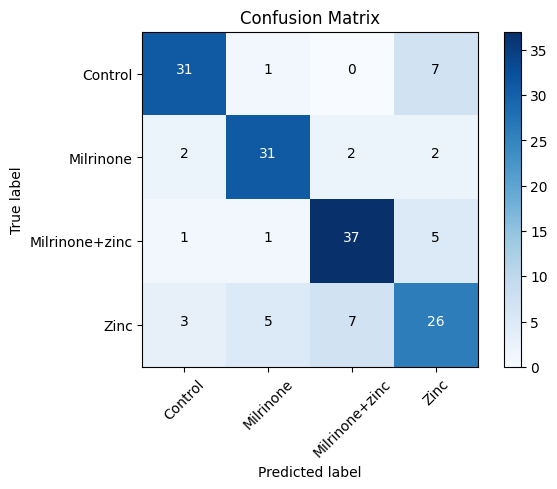

Accuracy Score: 0.7763975155279503
Precision Score: 0.7757837922348917
Recall Score: 0.7763975155279503
F1 Score: 0.7757839849220475
Classification Report:
                precision    recall  f1-score   support

       Control       0.84      0.79      0.82        39
     Milrinone       0.82      0.84      0.83        37
Milrinone+zinc       0.80      0.84      0.82        44
          Zinc       0.65      0.63      0.64        41

      accuracy                           0.78       161
     macro avg       0.78      0.78      0.78       161
  weighted avg       0.78      0.78      0.78       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.7763975155279503
Precision: 0.7769937844022512
Recall: 0.776941

train: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_2\train... 1100 images, 0 corrupt: 100%|██████████| 1100/110
val: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_2\val... 314 images, 0 corrupt: 100%|██████████| 314/314 [00:0


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\train2
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 45.62it/s]

                   all       0.51          1


...

      30/30     0.541G     0.5116         12        224: 100%|██████████| 69/69 [00:03<00:00, 21.85it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 60.13it/s]

                   all      0.774          1



30 epochs completed in 0.038 hours.
Optimizer stripped from runs\classify\train2\weights\last.pt, 11.0MB
Optimizer stripped from runs\classify\train2\weights\best.pt, 11.0MB

Validating runs\classify\train2\weights\best.pt...
Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11s-cls summary (fused): 112 layers, 5,439,252 parameters, 0 gradients, 12.0 GFLOPs
train: C:\Users\conso\Desktop\qq\Mcells\Completed_2\train... found 1100 images in 4 classes  
val: C:\Users\conso\Desktop\qq\Mcells\Completed_2\val... found 314 images in 4 classes  
test: C:\Users\conso\Desktop\qq\Mcells\Completed_2\test... found 161 images in 4 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 44.88it/s]


                   all      0.806          1
Speed: 0.2ms preprocess, 0.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train2
-------------------------------
 Yolov11 S


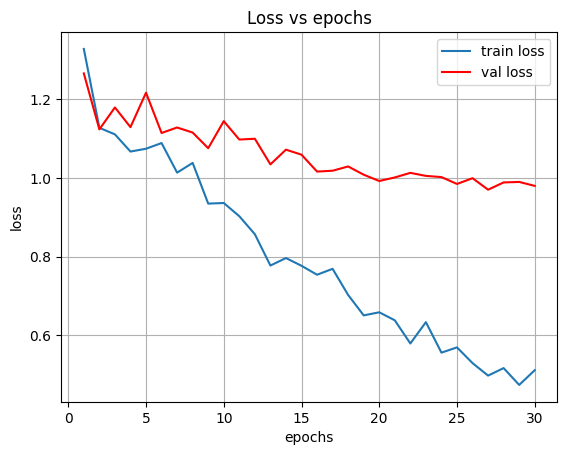

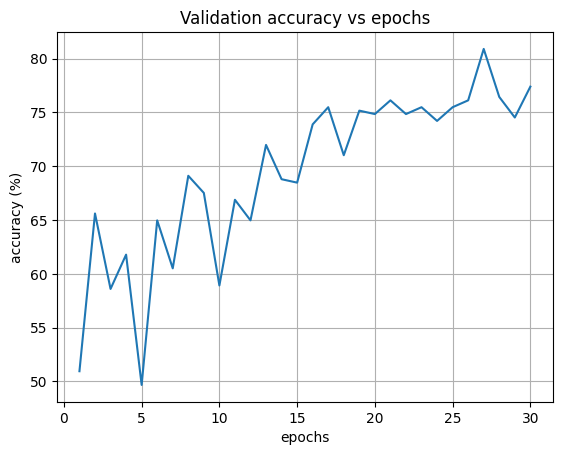

Load Best Model
Get the images from test directory for prediction

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 15.03.22 -02_1_0.jpg: 224x224 Milrinone+zinc 0.70, Control 0.13, Milrinone 0.09, Zinc 0.08, 19.3ms
Speed: 5.4ms preprocess, 19.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.1250385344028473, 0.09198012948036194, 0.6991075277328491, 0.08387386053800583]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 15.03.22 -03_1_0.jpg: 224x224 Control 0.90, Zinc 0.07, Milrinone+zinc 0.03, Milrinone 0.00, 11.1ms
Speed: 4.3ms preprocess, 11.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8984098434448242, 0.0029885522089898586, 0.02766643837094307, 0.07093523442745209]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999960660934448, 2.770871560642263e-06, 2.0397202149524674e-07, 9.446702620152791e-07]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.05.22 D004-02_1_2.jpg: 224x224 Control 0.99, Zinc 0.00, Milrinone 0.00, Milrinone+zinc 0.00, 13.3ms
Speed: 4.4ms preprocess, 13.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9940939545631409, 0.0023554146755486727, 0.0009625825332477689, 0.002587986411526799]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.05.22 D004-02_2_1.jpg: 224x224 Control 0.87, Milrinone 0.13, Milrinone+zinc 0.00, Zinc 0.00, 12.4ms
Speed: 5.6ms preprocess, 12.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8716382384300232, 0.127513125538826, 0.000

Speed: 5.5ms preprocess, 6.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.984393298625946, 0.0005037010414525867, 0.015037886798381805, 6.503761687781662e-05]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22_0_1.jpg: 224x224 Zinc 0.63, Control 0.34, Milrinone 0.03, Milrinone+zinc 0.00, 5.8ms
Speed: 4.0ms preprocess, 5.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.34087204933166504, 0.026797186583280563, 0.0037455689162015915, 0.6285852193832397]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100  10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone 0.77, Control 0.20, Milrinone+zinc 0.02, Zinc 0.01, 5.5ms
Speed: 4.0ms preprocess, 5.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milr

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_0_2.jpg: 224x224 Milrinone 0.84, Zinc 0.07, Control 0.07, Milrinone+zinc 0.02, 6.4ms
Speed: 3.1ms preprocess, 6.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.06712083518505096, 0.8444726467132568, 0.018980540335178375, 0.06942601501941681]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_2_2.jpg: 224x224 Milrinone+zinc 0.47, Zinc 0.30, Control 0.21, Milrinone 0.02, 6.2ms
Speed: 3.1ms preprocess, 6.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.20942562818527222, 0.019706962630152702, 0.4675474762916565, 0.30331987142562866]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 Milrinone 25.05.22 D004-0

Speed: 3.0ms preprocess, 6.6ms inference, 0.2ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00015909774811007082, 0.9805057644844055, 0.0188913531601429, 0.0004438280884642154]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_2_2.jpg: 224x224 Milrinone 0.98, Milrinone+zinc 0.02, Control 0.00, Zinc 0.00, 4.3ms
Speed: 6.9ms preprocess, 4.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.004076048266142607, 0.9755284190177917, 0.019441409036517143, 0.0009540363680571318]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100  Zinc+ 10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Control 0.00, Milrinone 0.00, 8.8ms
Speed: 0.5ms preprocess, 8.8ms inference, 0.0ms postprocess per image at shape (1, 3, 22

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_2_0.jpg: 224x224 Milrinone+zinc 0.99, Control 0.00, Zinc 0.00, Milrinone 0.00, 6.2ms
Speed: 2.9ms preprocess, 6.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.004949461203068495, 4.020187407149933e-05, 0.9948380589485168, 0.00017218691937159747]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-05_0_2.jpg: 224x224 Milrinone+zinc 0.87, Zinc 0.12, Control 0.00, Milrinone 0.00, 7.1ms
Speed: 2.7ms preprocess, 7.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.004635172430425882, 0.0023336783051490784, 0.8694829344749451, 0.12354821711778641]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_0.jpg: 224x224 Milrinone+zinc 0.99, Milrinone 0.00, Zinc 0.00, Control 0.00, 7.6ms
Speed: 3.7ms preprocess, 7.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.000164006749400869, 0.004563494585454464, 0.9935595989227295, 0.0017128093168139458]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_2.jpg: 224x224 Milrinone+zinc 0.99, Control 0.01, Zinc 0.00, Milrinone 0.00, 8.5ms
Speed: 4.6ms preprocess, 8.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.007239071186631918, 0.0004314714460633695, 0.9883155822753906, 0.004013914614915848]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2

Speed: 3.3ms preprocess, 5.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0025368575006723404, 0.05849938094615936, 4.475297828321345e-05, 0.938918948173523]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -04_2_2.jpg: 224x224 Zinc 0.63, Control 0.21, Milrinone 0.16, Milrinone+zinc 0.00, 6.8ms
Speed: 2.8ms preprocess, 6.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.2066306471824646, 0.15658000111579895, 0.0025766086764633656, 0.6342127919197083]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 _0_0.jpg: 224x224 Zinc 0.93, Control 0.05, Milrinone+zinc 0.01, Milrinone 0.01, 6.2ms
Speed: 3.5ms preprocess, 6.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrin

Speed: 5.9ms preprocess, 14.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.3205816884465094e-08, 1.0353401194151957e-06, 0.20324298739433289, 0.7967559099197388]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21_0_2.jpg: 224x224 Zinc 0.99, Milrinone+zinc 0.00, Milrinone 0.00, Control 0.00, 14.8ms
Speed: 3.7ms preprocess, 14.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0001341331662843004, 0.0030748501885682344, 0.004595737438648939, 0.9921952486038208]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib100 100uM Zn2+ 20.01.22-03_1_0.jpg: 224x224 Zinc 0.99, Milrinone+zinc 0.01, Milrinone 0.00, Control 0.00, 14.3ms
Speed: 4.3ms preprocess, 14.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Mil

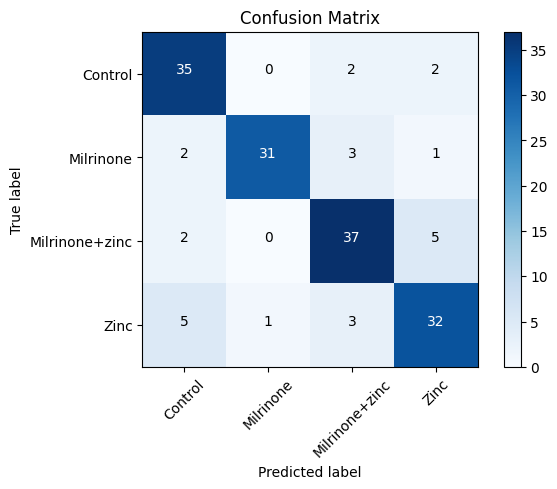

Accuracy Score: 0.8385093167701864
Precision Score: 0.8437531369596586
Recall Score: 0.8385093167701864
F1 Score: 0.8392377296147258
Classification Report:
                precision    recall  f1-score   support

       Control       0.80      0.90      0.84        39
     Milrinone       0.97      0.84      0.90        37
Milrinone+zinc       0.82      0.84      0.83        44
          Zinc       0.80      0.78      0.79        41

      accuracy                           0.84       161
     macro avg       0.85      0.84      0.84       161
  weighted avg       0.84      0.84      0.84       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8385093167701864
Precision: 0.8466066919191919
Recall: 0.839167

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-04_2_0.jpg: 224x224 Control 0.98, Milrinone 0.01, Milrinone+zinc 0.01, Zinc 0.01, 6.0ms
Speed: 3.1ms preprocess, 6.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9799556136131287, 0.007820751518011093, 0.007002408150583506, 0.005221263039857149]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-05_0_2.jpg: 224x224 Control 0.91, Milrinone 0.08, Milrinone+zinc 0.01, Zinc 0.00, 7.0ms
Speed: 3.5ms preprocess, 7.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9065198302268982, 0.0780399963259697, 0.011094736866652966, 0.004345393739640713]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-05_2_2.jpg: 224x224 Co

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9982858300209045, 3.1624270491192874e-07, 0.0017135251546278596, 3.191701694049698e-07]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-05_2_0.jpg: 224x224 Control 1.00, Milrinone+zinc 0.00, Zinc 0.00, Milrinone 0.00, 6.8ms
Speed: 1.6ms preprocess, 6.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9991129040718079, 8.001638889254536e-06, 0.0007909959531389177, 8.811138104647398e-05]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-07_1_2.jpg: 224x224 Milrinone+zinc 0.83, Control 0.14, Milrinone 0.02, Zinc 0.00, 10.4ms
Speed: 7.3ms preprocess, 10.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.14309899508953094, 0.024464089423418045, 0.831416547298

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_0.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Zinc 0.00, Control 0.00, 6.3ms
Speed: 4.9ms preprocess, 6.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.9243497920106165e-05, 0.9954977035522461, 0.004282692912966013, 0.0001903381635202095]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_1.jpg: 224x224 Milrinone 0.43, Control 0.28, Milrinone+zinc 0.17, Zinc 0.11, 9.0ms
Speed: 4.3ms preprocess, 9.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.27972230315208435, 0.4337006211280823, 0.17246578633785248, 0.11411120742559433]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.

Speed: 3.0ms preprocess, 5.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.1913517283801411e-07, 0.999996542930603, 3.3460164559073746e-06, 5.159118909858762e-09]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_2.jpg: 224x224 Milrinone 0.93, Control 0.07, Milrinone+zinc 0.01, Zinc 0.00, 7.1ms
Speed: 2.3ms preprocess, 7.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0650215595960617, 0.9266548752784729, 0.00825361255556345, 6.993630086071789e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_1.jpg: 224x224 Milrinone 0.99, Milrinone+zinc 0.01, Zinc 0.00, Control 0.00, 3.9ms
Speed: 2.5ms preprocess, 3.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Contr

Speed: 1.7ms preprocess, 4.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.924466902091808e-07, 5.083933956484543e-06, 0.9817056655883789, 0.01828858256340027]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Zinc 0.00, Milrinone 0.00, 12.3ms
Speed: 4.9ms preprocess, 12.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.2639032977167517e-05, 4.844370664613962e-07, 0.9999581575393677, 1.8697743144002743e-05]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_1.jpg: 224x224 Milrinone+zinc 0.75, Zinc 0.25, Milrinone 0.00, Control 0.00, 7.2ms
Speed: 0.0ms preprocess, 7.2ms inference, 0.0ms postprocess per 

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_1_0.jpg: 224x224 Control 0.97, Zinc 0.03, Milrinone+zinc 0.00, Milrinone 0.00, 10.9ms
Speed: 5.0ms preprocess, 10.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9690591096878052, 9.786257578525692e-05, 0.0028192028403282166, 0.028023824095726013]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_2_2.jpg: 224x224 Milrinone+zinc 0.48, Zinc 0.45, Control 0.04, Milrinone 0.03, 12.5ms
Speed: 4.3ms preprocess, 12.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.04177561774849892, 0.026142239570617676, 0.4787527620792389, 0.4533294439315796]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100  Zinc 100uM 25.03.22 D025_2_2.jpg: 224x224 Zinc 0.91, Milrinone+zinc 0.09, Control 0.00, Milrinone 0.00, 7.8ms
Speed: 3.4ms preprocess, 7.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0003560186887625605, 0.00023884304391685873, 0.0904281884431839, 0.9089770317077637]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_0_2.jpg: 224x224 Zinc 0.73, Milrinone 0.25, Control 0.01, Milrinone+zinc 0.00, 4.6ms
Speed: 3.2ms preprocess, 4.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.01136152632534504, 0.2532286047935486, 0.0034283017739653587, 0.7319815754890442]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_2_1.jpg: 224x224 Zinc 0.90, Contro

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-03_0_0.jpg: 224x224 Milrinone+zinc 0.73, Zinc 0.27, Milrinone 0.00, Control 0.00, 6.5ms
Speed: 4.7ms preprocess, 6.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.9298018116842286e-07, 1.396709762957471e-06, 0.7297172546386719, 0.2702811062335968]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-03_2_2.jpg: 224x224 Milrinone+zinc 0.66, Control 0.24, Zinc 0.09, Milrinone 0.01, 4.8ms
Speed: 2.2ms preprocess, 4.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.24332430958747864, 0.009763805195689201, 0.6590808033943176, 0.08783109486103058]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_1.jpg: 224x224 Milrinone+zinc 0.67,

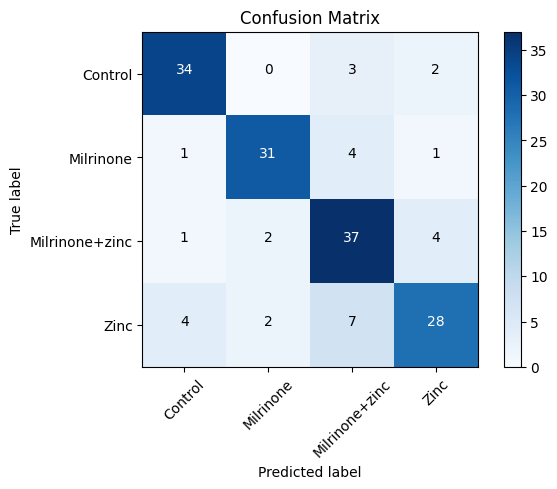

Accuracy Score: 0.8074534161490683
Precision Score: 0.8114471875706805
Recall Score: 0.8074534161490683
F1 Score: 0.8069251049105061
Classification Report:
                precision    recall  f1-score   support

       Control       0.85      0.87      0.86        39
     Milrinone       0.89      0.84      0.86        37
Milrinone+zinc       0.73      0.84      0.78        44
          Zinc       0.80      0.68      0.74        41

      accuracy                           0.81       161
     macro avg       0.82      0.81      0.81       161
  weighted avg       0.81      0.81      0.81       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8074534161490683
Precision: 0.8153011204481793
Recall: 0.808367

train: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_2\train... 1100 images, 0 corrupt: 100%|██████████| 1100/110
val: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_2\val... 314 images, 0 corrupt: 100%|██████████| 314/314 [00:0


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 49 weight(decay=0.0), 50 weight(decay=0.0005), 50 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\train3
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 27.95it/s]

                   all      0.529          1


...

      30/30      1.16G     0.4946         12        224: 100%|██████████| 69/69 [00:04<00:00, 15.22it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 34.32it/s]

                   all      0.796          1



30 epochs completed in 0.052 hours.
Optimizer stripped from runs\classify\train3\weights\last.pt, 20.9MB
Optimizer stripped from runs\classify\train3\weights\best.pt, 20.9MB

Validating runs\classify\train3\weights\best.pt...
Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11m-cls summary (fused): 138 layers, 10,346,756 parameters, 0 gradients, 39.3 GFLOPs
train: C:\Users\conso\Desktop\qq\Mcells\Completed_2\train... found 1100 images in 4 classes  
val: C:\Users\conso\Desktop\qq\Mcells\Completed_2\val... found 314 images in 4 classes  
test: C:\Users\conso\Desktop\qq\Mcells\Completed_2\test... found 161 images in 4 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 27.54it/s]


                   all      0.828          1
Speed: 0.3ms preprocess, 0.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train3
-------------------------------
 Yolov11 M


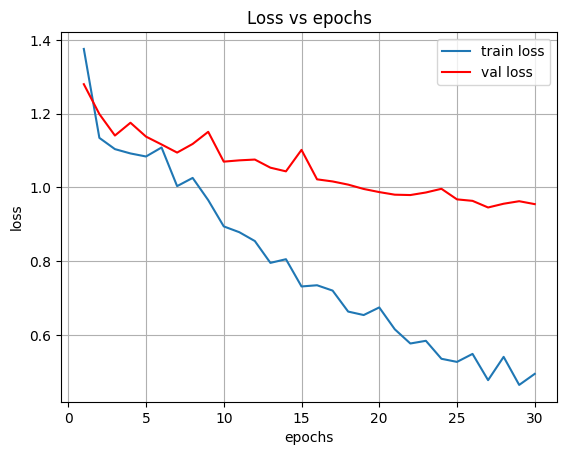

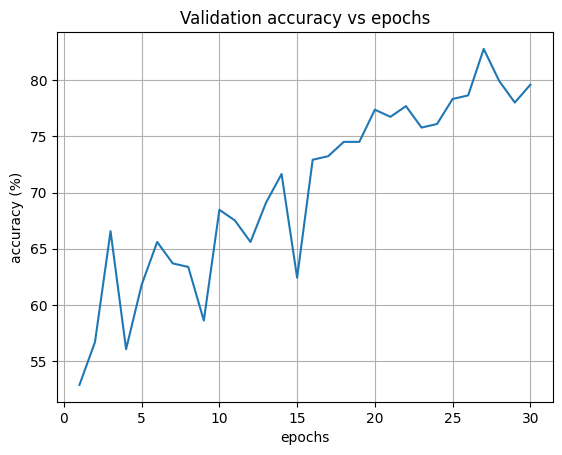

Load Best Model
Get the images from test directory for prediction

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 15.03.22 -02_1_0.jpg: 224x224 Zinc 0.93, Control 0.04, Milrinone+zinc 0.02, Milrinone 0.01, 8.3ms
Speed: 4.2ms preprocess, 8.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.03577273339033127, 0.010510564781725407, 0.02202111855149269, 0.9316955804824829]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 15.03.22 -03_1_0.jpg: 224x224 Control 0.82, Zinc 0.17, Milrinone+zinc 0.01, Milrinone 0.00, 9.2ms
Speed: 4.1ms preprocess, 9.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8224607706069946, 0.003653216641396284, 0.00783054530620575, 0.16605547070503235]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Contro

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999886751174927, 9.556683835398871e-07, 2.5379517865076195e-06, 7.918496521597262e-06]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.05.22 D004-02_1_2.jpg: 224x224 Control 0.98, Milrinone 0.01, Zinc 0.00, Milrinone+zinc 0.00, 10.6ms
Speed: 4.3ms preprocess, 10.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9847947955131531, 0.00702393613755703, 0.0036504848394542933, 0.004530874080955982]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.05.22 D004-02_2_1.jpg: 224x224 Control 0.75, Milrinone 0.25, Milrinone+zinc 0.00, Zinc 0.00, 8.4ms
Speed: 4.1ms preprocess, 8.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.7466111779212952, 0.2503601610660553, 0.002709

Speed: 4.0ms preprocess, 8.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.993239164352417, 0.0038326354697346687, 0.002738662762567401, 0.00018950992671307176]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22_0_1.jpg: 224x224 Control 0.86, Milrinone+zinc 0.05, Milrinone 0.04, Zinc 0.04, 9.2ms
Speed: 4.4ms preprocess, 9.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8643166422843933, 0.04312837868928909, 0.05265212431550026, 0.039902906864881516]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100  10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone 0.84, Milrinone+zinc 0.14, Zinc 0.02, Control 0.00, 8.9ms
Speed: 5.0ms preprocess, 8.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Mi

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_0_2.jpg: 224x224 Milrinone 0.59, Zinc 0.28, Control 0.07, Milrinone+zinc 0.06, 9.3ms
Speed: 4.3ms preprocess, 9.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.07487225532531738, 0.5878657698631287, 0.059883639216423035, 0.2773783206939697]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_2_2.jpg: 224x224 Control 0.44, Zinc 0.32, Milrinone+zinc 0.18, Milrinone 0.06, 9.3ms
Speed: 4.2ms preprocess, 9.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.4399993121623993, 0.061642345041036606, 0.18269380927085876, 0.31566447019577026]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 Milrinone 25.05.22 D004-03_1_2.jp

Speed: 4.6ms preprocess, 6.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.41446757374797e-05, 0.9911064505577087, 0.008849875070154667, 9.58573855314171e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_2_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 8.1ms
Speed: 4.4ms preprocess, 8.1ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00016501086065545678, 0.9970955848693848, 0.002725941361859441, 1.3469635632645804e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100  Zinc+ 10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Control 0.00, Milrinone 0.00, 7.5ms
Speed: 3.7ms preprocess, 7.5ms inference, 0.0ms postprocess per image at shape (1, 3, 

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_2_0.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Control 0.00, Milrinone 0.00, 6.0ms
Speed: 5.1ms preprocess, 6.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0005364850512705743, 1.2042364687658846e-05, 0.9988057613372803, 0.000645685417111963]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-05_0_2.jpg: 224x224 Milrinone+zinc 0.70, Zinc 0.30, Control 0.00, Milrinone 0.00, 13.6ms
Speed: 5.3ms preprocess, 13.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00012095682905055583, 5.554976814892143e-05, 0.7040805220603943, 0.29574301838874817]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milri

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_0.jpg: 224x224 Milrinone+zinc 1.00, Milrinone 0.00, Control 0.00, Zinc 0.00, 9.0ms
Speed: 3.0ms preprocess, 9.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00011363105295458809, 0.0030196900479495525, 0.9968551397323608, 1.1507398994581308e-05]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_2.jpg: 224x224 Milrinone+zinc 0.89, Control 0.10, Milrinone 0.00, Zinc 0.00, 8.7ms
Speed: 3.2ms preprocess, 8.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.10254678130149841, 0.00288048735819757, 0.8935192227363586, 0.0010534852044656873]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed

Speed: 3.0ms preprocess, 8.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.13052211701869965, 0.05429239943623543, 0.006562631577253342, 0.8086228966712952]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -04_2_2.jpg: 224x224 Zinc 0.53, Control 0.21, Milrinone 0.17, Milrinone+zinc 0.08, 9.0ms
Speed: 3.1ms preprocess, 9.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.20979920029640198, 0.17358604073524475, 0.08359087258577347, 0.5330238342285156]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 _0_0.jpg: 224x224 Zinc 0.56, Milrinone+zinc 0.25, Control 0.09, Milrinone 0.09, 10.1ms
Speed: 1.4ms preprocess, 10.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrino

Speed: 3.5ms preprocess, 8.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[4.1133051809083554e-07, 1.922880437632557e-05, 0.01797068677842617, 0.9820097088813782]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21_0_2.jpg: 224x224 Zinc 0.87, Milrinone+zinc 0.09, Milrinone 0.03, Control 0.00, 12.4ms
Speed: 0.0ms preprocess, 12.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.004044904839247465, 0.027805380523204803, 0.09476467967033386, 0.8733850121498108]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib100 100uM Zn2+ 20.01.22-03_1_0.jpg: 224x224 Zinc 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Control 0.00, 10.4ms
Speed: 3.3ms preprocess, 10.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinon

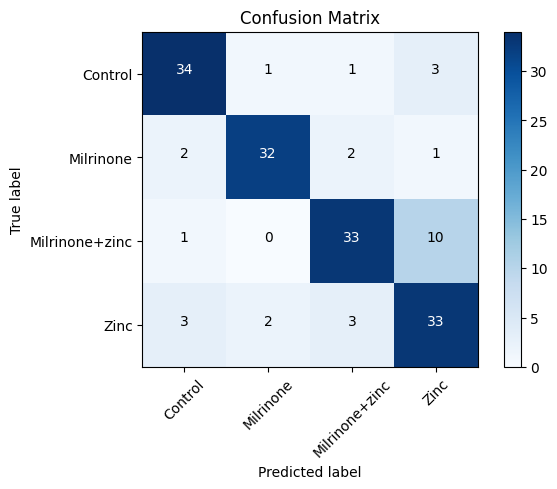

Accuracy Score: 0.8198757763975155
Precision Score: 0.8260656813782227
Recall Score: 0.8198757763975155
F1 Score: 0.8210960307408843
Classification Report:
                precision    recall  f1-score   support

       Control       0.85      0.87      0.86        39
     Milrinone       0.91      0.86      0.89        37
Milrinone+zinc       0.85      0.75      0.80        44
          Zinc       0.70      0.80      0.75        41

      accuracy                           0.82       161
     macro avg       0.83      0.82      0.82       161
  weighted avg       0.83      0.82      0.82       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8198757763975155
Precision: 0.8281418050035072
Recall: 0.822884

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-04_2_0.jpg: 224x224 Control 0.78, Milrinone 0.20, Milrinone+zinc 0.02, Zinc 0.00, 14.2ms
Speed: 4.1ms preprocess, 14.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.7795104384422302, 0.20258131623268127, 0.017553644254803658, 0.00035465636756271124]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-05_0_2.jpg: 224x224 Control 0.62, Milrinone 0.38, Milrinone+zinc 0.01, Zinc 0.00, 12.2ms
Speed: 6.1ms preprocess, 12.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.617355227470398, 0.3754902184009552, 0.00706692086532712, 8.769717533141375e-05]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-05_2_2.jpg: 224x22

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9939458966255188, 6.411716185539262e-06, 0.00598950544372201, 5.8117948356084526e-05]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-05_2_0.jpg: 224x224 Control 0.60, Zinc 0.25, Milrinone+zinc 0.14, Milrinone 0.01, 9.1ms
Speed: 3.4ms preprocess, 9.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.5992876887321472, 0.012568589299917221, 0.14304398000240326, 0.245099738240242]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-07_1_2.jpg: 224x224 Control 0.99, Milrinone+zinc 0.01, Milrinone 0.00, Zinc 0.00, 10.0ms
Speed: 3.0ms preprocess, 10.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9852936863899231, 0.00414381455630064, 0.009600509889423847, 0.0

Speed: 3.3ms preprocess, 8.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[5.435631828731857e-05, 0.9977465271949768, 0.002166092162951827, 3.2986827136483043e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_1.jpg: 224x224 Control 0.43, Milrinone 0.34, Zinc 0.15, Milrinone+zinc 0.08, 9.8ms
Speed: 2.1ms preprocess, 9.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.42638784646987915, 0.33953729271888733, 0.08274703472852707, 0.15132781863212585]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_2_0.jpg: 224x224 Milrinone 0.98, Milrinone+zinc 0.02, Control 0.00, Zinc 0.00, 8.9ms
Speed: 6.7ms preprocess, 8.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0:

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.287202995736152e-05, 0.999932050704956, 5.036095444665989e-06, 1.1703416902264507e-08]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_2.jpg: 224x224 Milrinone 1.00, Control 0.00, Milrinone+zinc 0.00, Zinc 0.00, 10.3ms
Speed: 3.5ms preprocess, 10.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0020280207972973585, 0.9963502883911133, 0.001617671805433929, 3.979672783316346e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_1.jpg: 224x224 Milrinone 0.84, Milrinone+zinc 0.16, Control 0.00, Zinc 0.00, 8.4ms
Speed: 3.2ms preprocess, 8.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[4.6504512283718213e-05, 0.83561611175

Speed: 3.6ms preprocess, 9.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.346957601024769e-05, 7.600793469464406e-05, 0.7454606294631958, 0.2544298470020294]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Zinc 0.00, Milrinone 0.00, 6.7ms
Speed: 3.0ms preprocess, 6.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0004842275520786643, 7.344887080762419e-07, 0.9995002746582031, 1.4739618563908152e-05]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_1.jpg: 224x224 Zinc 0.78, Milrinone+zinc 0.22, Control 0.00, Milrinone 0.00, 9.6ms
Speed: 3.1ms preprocess, 9.6ms inference, 0.0ms postprocess per imag

Speed: 3.1ms preprocess, 9.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.10711980611085892, 0.0008977422839961946, 0.010445965453982353, 0.8815364837646484]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_2_2.jpg: 224x224 Milrinone+zinc 0.56, Zinc 0.42, Control 0.01, Milrinone 0.01, 9.5ms
Speed: 3.3ms preprocess, 9.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.013922611251473427, 0.009449243545532227, 0.5554386377334595, 0.42118939757347107]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-05_1_1.jpg: 224x224 Zinc 0.49, Milrinone+zinc 0.28, Control 0.18, Milrinone 0.04, 9.1ms
Speed: 4.1ms preprocess, 9.1ms inference, 0.0ms postprocess per ima

Speed: 2.0ms preprocess, 6.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[5.8491887102718465e-06, 0.00014758970064576715, 0.027873270213603973, 0.9719732403755188]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_0_2.jpg: 224x224 Milrinone 0.69, Zinc 0.24, Control 0.06, Milrinone+zinc 0.00, 9.3ms
Speed: 5.1ms preprocess, 9.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0628875121474266, 0.6943294405937195, 0.004682325292378664, 0.23810073733329773]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_2_1.jpg: 224x224 Milrinone 0.66, Zinc 0.22, Control 0.12, Milrinone+zinc 0.01, 9.9ms
Speed: 5.0ms preprocess, 9.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone',

Speed: 4.9ms preprocess, 8.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.926297828613315e-07, 1.8157565136789344e-05, 0.573214590549469, 0.426766574382782]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-03_2_2.jpg: 224x224 Milrinone+zinc 0.52, Control 0.32, Zinc 0.15, Milrinone 0.01, 8.5ms
Speed: 3.0ms preprocess, 8.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.3221675455570221, 0.014892878010869026, 0.5163882970809937, 0.14655131101608276]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_1.jpg: 224x224 Milrinone+zinc 0.91, Zinc 0.08, Milrinone 0.01, Control 0.00, 7.5ms
Speed: 3.9ms preprocess, 7.5ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 

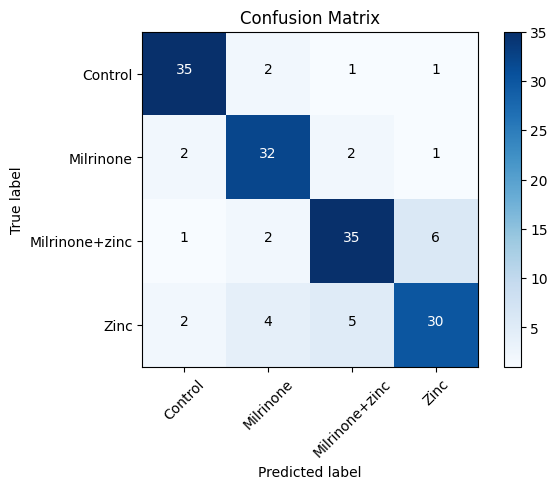

Accuracy Score: 0.8198757763975155
Precision Score: 0.8193004629876005
Recall Score: 0.8198757763975155
F1 Score: 0.8189549573631493
Classification Report:
                precision    recall  f1-score   support

       Control       0.88      0.90      0.89        39
     Milrinone       0.80      0.86      0.83        37
Milrinone+zinc       0.81      0.80      0.80        44
          Zinc       0.79      0.73      0.76        41

      accuracy                           0.82       161
     macro avg       0.82      0.82      0.82       161
  weighted avg       0.82      0.82      0.82       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8198757763975155
Precision: 0.8196067931456548
Recall: 0.822365

train: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_2\train... 1100 images, 0 corrupt: 100%|██████████| 1100/110
val: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_2\val... 314 images, 0 corrupt: 100%|██████████| 314/314 [00:0


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 82 weight(decay=0.0), 83 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\train4
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 22.74it/s]

                   all       0.57          1


...

      30/30      1.59G     0.4684         12        224: 100%|██████████| 69/69 [00:11<00:00,  5.88it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 15.56it/s]

                   all      0.822          1



30 epochs completed in 0.088 hours.
Optimizer stripped from runs\classify\train4\weights\last.pt, 25.9MB
Optimizer stripped from runs\classify\train4\weights\best.pt, 25.9MB

Validating runs\classify\train4\weights\best.pt...
Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11l-cls summary (fused): 227 layers, 12,823,556 parameters, 0 gradients, 49.3 GFLOPs
train: C:\Users\conso\Desktop\qq\Mcells\Completed_2\train... found 1100 images in 4 classes  
val: C:\Users\conso\Desktop\qq\Mcells\Completed_2\val... found 314 images in 4 classes  
test: C:\Users\conso\Desktop\qq\Mcells\Completed_2\test... found 161 images in 4 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 18.72it/s]


                   all      0.822          1
Speed: 0.2ms preprocess, 1.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train4
-------------------------------
 Yolov11 L


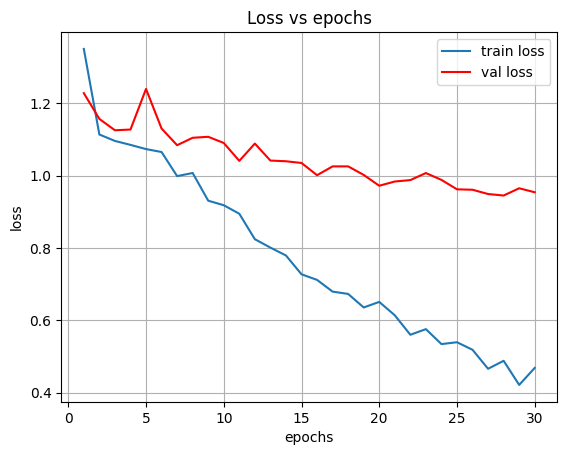

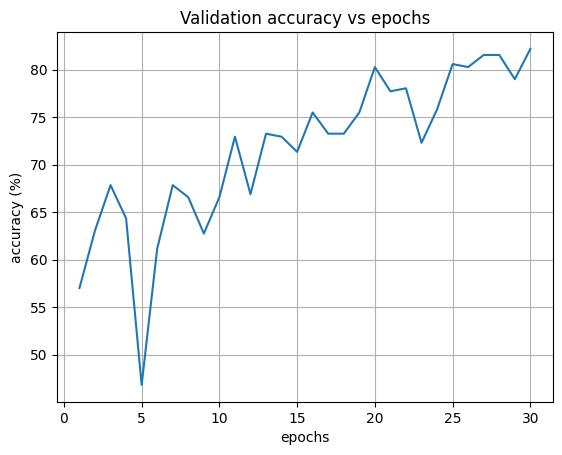

Load Best Model
Get the images from test directory for prediction

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 15.03.22 -02_1_0.jpg: 224x224 Control 0.99, Zinc 0.00, Milrinone 0.00, Milrinone+zinc 0.00, 38.2ms
Speed: 6.6ms preprocess, 38.2ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9933199882507324, 0.0018308373400941491, 0.0009473937097936869, 0.003901776624843478]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 15.03.22 -03_1_0.jpg: 224x224 Control 0.60, Zinc 0.39, Milrinone+zinc 0.01, Milrinone 0.01, 34.1ms
Speed: 6.8ms preprocess, 34.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.5961745977401733, 0.008155115880072117, 0.009963272139430046, 0.3857070207595825]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999500513076782, 4.037921462440863e-05, 7.499108960473677e-06, 2.008637920880574e-06]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.05.22 D004-02_1_2.jpg: 224x224 Control 0.99, Milrinone 0.01, Zinc 0.00, Milrinone+zinc 0.00, 20.0ms
Speed: 6.0ms preprocess, 20.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9942498207092285, 0.005084028001874685, 0.00023850217985454947, 0.00042773300083354115]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.05.22 D004-02_2_1.jpg: 224x224 Control 0.93, Milrinone 0.07, Milrinone+zinc 0.01, Zinc 0.00, 22.3ms
Speed: 4.8ms preprocess, 22.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9250375032424927, 0.06961466372013092, 0.

Speed: 4.1ms preprocess, 21.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999974966049194, 1.6984024568955647e-06, 7.203891527751694e-07, 6.08717414252169e-08]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22_0_1.jpg: 224x224 Zinc 0.52, Control 0.44, Milrinone+zinc 0.03, Milrinone 0.00, 23.5ms
Speed: 5.9ms preprocess, 23.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.4429663419723511, 0.0038222703151404858, 0.03036719374358654, 0.5228441953659058]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100  10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone+zinc 0.64, Milrinone 0.31, Zinc 0.04, Control 0.00, 32.3ms
Speed: 8.3ms preprocess, 32.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.001000886200927198, 0.3480987250804901, 0.6442516446113586, 0.006648751441389322]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_0_2.jpg: 224x224 Milrinone 0.74, Zinc 0.17, Control 0.05, Milrinone+zinc 0.03, 42.2ms
Speed: 9.5ms preprocess, 42.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.05456036329269409, 0.7439532279968262, 0.0307051669806242, 0.17078126966953278]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_2_2.jpg: 224x224 Zinc 0.60, Control 0.19, Milrinone+zinc 0.13, Milrinone 0.07, 49.2ms
Speed: 12.3ms preprocess, 49.2ms inference, 2.9ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.1946532428264618, 0.07340460270643

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 22.1ms
Speed: 4.3ms preprocess, 22.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00012135668657720089, 0.9967727065086365, 0.0030878314282745123, 1.8052653103950433e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_2_2.jpg: 224x224 Milrinone 0.96, Control 0.02, Milrinone+zinc 0.01, Zinc 0.00, 20.8ms
Speed: 5.7ms preprocess, 20.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.022809604182839394, 0.9649342894554138, 0.012011504732072353, 0.000244514289079234]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100  Zinc+ 10uM Milr

Speed: 5.4ms preprocess, 21.7ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.743620669003576e-05, 2.7472286092233844e-05, 0.4007599949836731, 0.599195122718811]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_2_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Zinc 0.00, Milrinone 0.00, 21.5ms
Speed: 6.7ms preprocess, 21.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0028000655584037304, 0.0007050171261653304, 0.9952309727668762, 0.0012639830820262432]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-05_0_2.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Milrinone 0.00, Control 0.00, 22.1ms
Speed: 5.2ms preprocess, 22.1ms inference, 0.0ms postprocess per image at s

Speed: 5.6ms preprocess, 20.8ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.017009424045681953, 0.0032136172521859407, 0.028214499354362488, 0.9515624046325684]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Milrinone 0.00, Zinc 0.00, 21.4ms
Speed: 5.9ms preprocess, 21.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[5.1548827286751475e-06, 2.4795037916192086e-06, 0.9999918937683105, 5.585540066022077e-07]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_2.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Milrinone 0.00, Zinc 0.00, 22.6ms
Speed: 6.9ms preprocess, 22.6ms inference, 0.0ms postpro

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.39699089527130127, 0.13957466185092926, 0.00543517991900444, 0.4579993486404419]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -03_1_0.jpg: 224x224 Zinc 0.95, Control 0.03, Milrinone 0.02, Milrinone+zinc 0.00, 22.3ms
Speed: 5.5ms preprocess, 22.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.02950829267501831, 0.01817602664232254, 0.000461545423604548, 0.9518540501594543]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -04_2_2.jpg: 224x224 Milrinone 0.86, Zinc 0.08, Control 0.04, Milrinone+zinc 0.02, 23.2ms
Speed: 5.4ms preprocess, 23.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.04286956414580345, 0.8623167872428894, 0.015959737822413445, 0.0788

Speed: 5.6ms preprocess, 17.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.16687292070128e-05, 0.0007615670328959823, 0.8506962060928345, 0.1485106348991394]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_2.jpg: 224x224 Zinc 0.99, Milrinone+zinc 0.01, Milrinone 0.00, Control 0.00, 20.6ms
Speed: 4.2ms preprocess, 20.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.769342917323229e-07, 5.360933573683724e-05, 0.0076571861281991005, 0.9922885298728943]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21_0_2.jpg: 224x224 Zinc 0.82, Milrinone+zinc 0.15, Milrinone 0.04, Control 0.00, 19.0ms
Speed: 5.0ms preprocess, 19.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'M

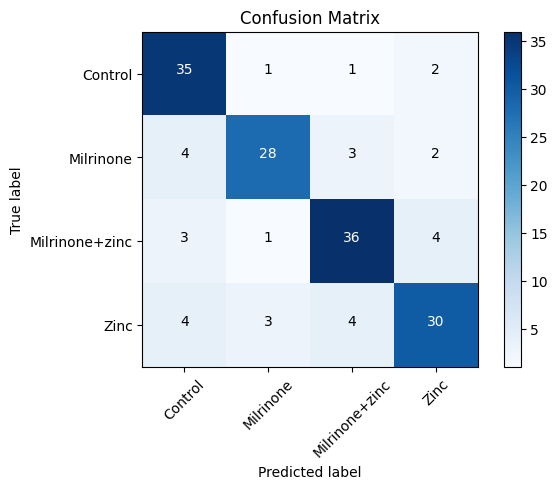

Accuracy Score: 0.8012422360248447
Precision Score: 0.8039520092549642
Recall Score: 0.8012422360248447
F1 Score: 0.8003533389139916
Classification Report:
                precision    recall  f1-score   support

       Control       0.76      0.90      0.82        39
     Milrinone       0.85      0.76      0.80        37
Milrinone+zinc       0.82      0.82      0.82        44
          Zinc       0.79      0.73      0.76        41

      accuracy                           0.80       161
     macro avg       0.80      0.80      0.80       161
  weighted avg       0.80      0.80      0.80       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8012422360248447
Precision: 0.804252479023646
Recall: 0.8010204

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-04_2_0.jpg: 224x224 Control 0.99, Milrinone 0.01, Milrinone+zinc 0.00, Zinc 0.00, 17.7ms
Speed: 4.5ms preprocess, 17.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9863646030426025, 0.009082488715648651, 0.003006027778610587, 0.0015468498459085822]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-05_0_2.jpg: 224x224 Control 0.98, Milrinone 0.01, Milrinone+zinc 0.01, Zinc 0.00, 18.8ms
Speed: 3.4ms preprocess, 18.8ms inference, 1.1ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9788148999214172, 0.014310711994767189, 0.005241274368017912, 0.0016330749494954944]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-05_2_2.jpg: 22

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9506614208221436, 4.78471565656946e-06, 0.049333252012729645, 5.567307539422472e-07]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-05_2_0.jpg: 224x224 Control 0.98, Milrinone+zinc 0.02, Zinc 0.00, Milrinone 0.00, 19.2ms
Speed: 4.6ms preprocess, 19.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9762045741081238, 0.00011045779683627188, 0.021901527419686317, 0.0017833327874541283]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-07_1_2.jpg: 224x224 Control 1.00, Milrinone 0.00, Milrinone+zinc 0.00, Zinc 0.00, 19.7ms
Speed: 5.0ms preprocess, 19.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9963672161102295, 0.002689320594072342, 0.00091759668430

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_0.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 19.7ms
Speed: 5.3ms preprocess, 19.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.0420536859310232e-05, 0.9998911619186401, 7.132411701604724e-05, 7.004073722782778e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_1.jpg: 224x224 Control 0.61, Milrinone+zinc 0.19, Milrinone 0.12, Zinc 0.07, 18.6ms
Speed: 4.3ms preprocess, 18.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.6135528087615967, 0.12452429533004761, 0.18728835880756378, 0.07463456690311432]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.

Speed: 5.5ms preprocess, 22.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.114403367973864e-05, 0.9985741376876831, 0.001364004099741578, 7.367307262029499e-07]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_2.jpg: 224x224 Milrinone 1.00, Control 0.00, Milrinone+zinc 0.00, Zinc 0.00, 24.0ms
Speed: 2.0ms preprocess, 24.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.001206616754643619, 0.9980541467666626, 0.0007341195596382022, 5.061247520643519e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_1.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 16.5ms
Speed: 4.4ms preprocess, 16.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0:

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_0_2.jpg: 224x224 Milrinone+zinc 0.99, Zinc 0.01, Milrinone 0.00, Control 0.00, 32.2ms
Speed: 7.0ms preprocess, 32.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[4.673219962114672e-07, 4.581344001053367e-06, 0.9927582740783691, 0.007236686069518328]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_0.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Control 0.00, Milrinone 0.00, 33.9ms
Speed: 7.2ms preprocess, 33.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[4.8632842663209885e-05, 3.741294131032191e-05, 0.9998359680175781, 7.79128386056982e-05]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Mil

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00031856028363108635, 0.06636250764131546, 0.9330585598945618, 0.0002604041073936969]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_1_0.jpg: 224x224 Control 0.92, Zinc 0.06, Milrinone+zinc 0.02, Milrinone 0.00, 19.8ms
Speed: 4.2ms preprocess, 19.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9211666584014893, 0.000824352668132633, 0.01658649556338787, 0.06142248585820198]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_2_2.jpg: 224x224 Zinc 0.66, Control 0.22, Milrinone+zinc 0.11, Milrinone 0.02, 19.3ms
Speed: 4.9ms preprocess, 19.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zin

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.001219054451212287, 0.0010382264154031873, 0.0292552150785923, 0.9684874415397644]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100  Zinc 100uM 25.03.22 D025_2_2.jpg: 224x224 Zinc 0.97, Milrinone+zinc 0.03, Control 0.00, Milrinone 0.00, 35.4ms
Speed: 5.0ms preprocess, 35.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[5.940003029536456e-05, 2.0314577341196127e-05, 0.026991378515958786, 0.9729289412498474]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_0_2.jpg: 224x224 Milrinone 0.95, Control 0.03, Zinc 0.01, Milrinone+zinc 0.00, 33.8ms
Speed: 3.9ms preprocess, 33.8ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.03397649899125099, 0.9510502219200134, 0.00025141303194686

Speed: 8.7ms preprocess, 43.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[8.418582183367107e-06, 4.1081540985032916e-05, 0.05053747445344925, 0.949413001537323]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-03_0_0.jpg: 224x224 Milrinone+zinc 0.57, Zinc 0.43, Milrinone 0.00, Control 0.00, 38.5ms
Speed: 7.4ms preprocess, 38.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.512569310260005e-05, 0.00011481279943836853, 0.5684719681739807, 0.4313780665397644]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-03_2_2.jpg: 224x224 Milrinone+zinc 0.54, Zinc 0.41, Milrinone 0.02, Control 0.02, 17.9ms
Speed: 4.2ms preprocess, 17.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2:

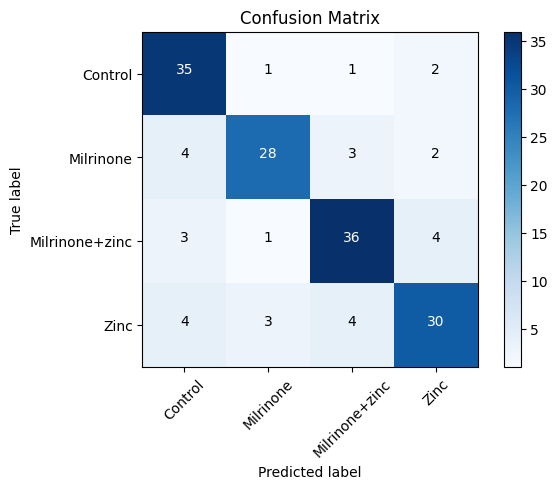

Accuracy Score: 0.8012422360248447
Precision Score: 0.8039520092549642
Recall Score: 0.8012422360248447
F1 Score: 0.8003533389139916
Classification Report:
                precision    recall  f1-score   support

       Control       0.76      0.90      0.82        39
     Milrinone       0.85      0.76      0.80        37
Milrinone+zinc       0.82      0.82      0.82        44
          Zinc       0.79      0.73      0.76        41

      accuracy                           0.80       161
     macro avg       0.80      0.80      0.80       161
  weighted avg       0.80      0.80      0.80       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8012422360248447
Precision: 0.804252479023646
Recall: 0.8010204

train: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_2\train... 1100 images, 0 corrupt: 100%|██████████| 1100/110
val: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_2\val... 314 images, 0 corrupt: 100%|██████████| 314/314 [00:0


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 82 weight(decay=0.0), 83 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\train5
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 13.54it/s]

                   all      0.541          1


...

      30/30      2.65G     0.5024         12        224: 100%|██████████| 69/69 [00:09<00:00,  7.56it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 20.60it/s]

                   all      0.777          1



30 epochs completed in 0.101 hours.
Optimizer stripped from runs\classify\train5\weights\last.pt, 57.0MB
Optimizer stripped from runs\classify\train5\weights\best.pt, 57.0MB

Validating runs\classify\train5\weights\best.pt...
Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11x-cls summary (fused): 227 layers, 28,337,540 parameters, 0 gradients, 110.3 GFLOPs
train: C:\Users\conso\Desktop\qq\Mcells\Completed_2\train... found 1100 images in 4 classes  
val: C:\Users\conso\Desktop\qq\Mcells\Completed_2\val... found 314 images in 4 classes  
test: C:\Users\conso\Desktop\qq\Mcells\Completed_2\test... found 161 images in 4 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 16.85it/s]


                   all       0.79          1
Speed: 0.1ms preprocess, 1.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train5
-------------------------------
 Yolov11 X


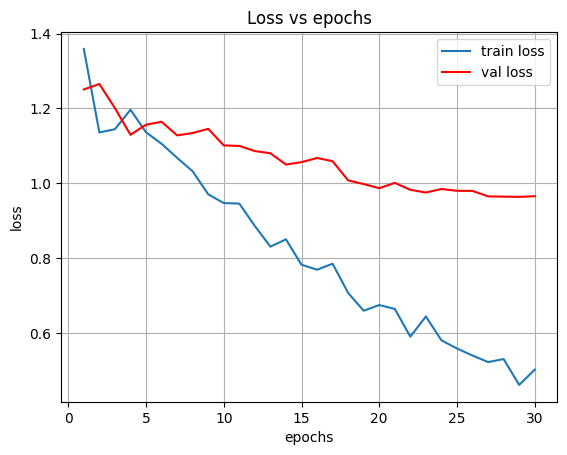

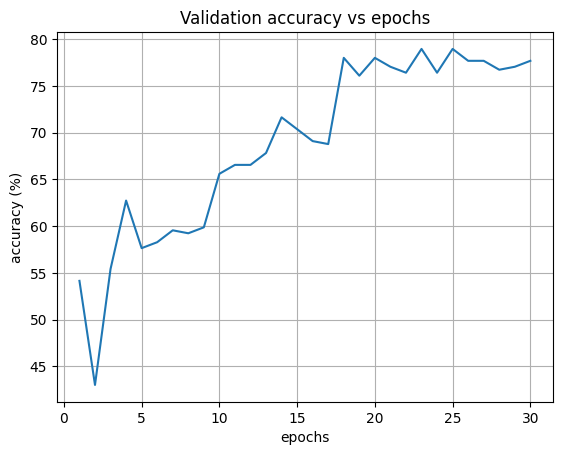

Load Best Model
Get the images from test directory for prediction

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 15.03.22 -02_1_0.jpg: 224x224 Milrinone+zinc 0.39, Zinc 0.33, Control 0.27, Milrinone 0.01, 18.0ms
Speed: 3.5ms preprocess, 18.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.26874691247940063, 0.012893008068203926, 0.3902285397052765, 0.3281314969062805]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 15.03.22 -03_1_0.jpg: 224x224 Zinc 0.75, Control 0.20, Milrinone+zinc 0.03, Milrinone 0.02, 24.4ms
Speed: 4.0ms preprocess, 24.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.19850395619869232, 0.018530426546931267, 0.02948146127164364, 0.7534841299057007]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\t

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999319314956665, 2.3225509266922018e-06, 5.8196266763843596e-05, 7.535506483691279e-06]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.05.22 D004-02_1_2.jpg: 224x224 Control 0.99, Milrinone 0.01, Zinc 0.00, Milrinone+zinc 0.00, 17.8ms
Speed: 5.0ms preprocess, 17.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9882155656814575, 0.007264968007802963, 0.0018318925285711884, 0.002687571570277214]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.05.22 D004-02_2_1.jpg: 224x224 Control 0.99, Milrinone 0.01, Milrinone+zinc 0.00, Zinc 0.00, 17.5ms
Speed: 5.2ms preprocess, 17.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9913673996925354, 0.008125347085297108, 0.

Speed: 4.4ms preprocess, 17.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.999639630317688, 5.772865188191645e-05, 9.387664613313973e-05, 0.00020868677529506385]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22_0_1.jpg: 224x224 Zinc 0.76, Control 0.20, Milrinone+zinc 0.04, Milrinone 0.01, 17.9ms
Speed: 4.0ms preprocess, 17.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.19808229804039001, 0.00988173857331276, 0.03574983403086662, 0.7562861442565918]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100  10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone 0.86, Milrinone+zinc 0.08, Control 0.04, Zinc 0.02, 17.0ms
Speed: 4.8ms preprocess, 17.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: '

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_0_2.jpg: 224x224 Milrinone 0.84, Zinc 0.13, Milrinone+zinc 0.02, Control 0.01, 19.4ms
Speed: 5.3ms preprocess, 19.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.013890468515455723, 0.8386877179145813, 0.0170377716422081, 0.13038413226604462]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_2_2.jpg: 224x224 Zinc 0.99, Milrinone 0.01, Milrinone+zinc 0.00, Control 0.00, 18.1ms
Speed: 5.3ms preprocess, 18.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00023906152637209743, 0.0055192094296216965, 0.0040397425182163715, 0.990202009677887]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 Milrinone 25.05.22 D004-03_

Speed: 4.8ms preprocess, 20.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00022281684505287558, 0.9434120655059814, 0.056236885488033295, 0.0001281836739508435]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_2_2.jpg: 224x224 Milrinone 0.98, Control 0.01, Milrinone+zinc 0.01, Zinc 0.00, 20.0ms
Speed: 4.9ms preprocess, 20.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.013709166087210178, 0.9791167378425598, 0.006897577550262213, 0.000276484148344025]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100  Zinc+ 10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Zinc 0.00, Milrinone 0.00, 19.9ms
Speed: 4.6ms preprocess, 19.9ms inference, 0.0ms postprocess per image at shape (1,

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_2_0.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Milrinone 0.00, Control 0.00, 19.8ms
Speed: 3.9ms preprocess, 19.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[8.157675438269507e-06, 9.122171832132153e-06, 0.9990500807762146, 0.0009326794533990324]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-05_0_2.jpg: 224x224 Milrinone+zinc 0.60, Zinc 0.40, Control 0.00, Milrinone 0.00, 23.7ms
Speed: 4.6ms preprocess, 23.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.1345686289132573e-05, 6.3300190049631055e-06, 0.5990117192268372, 0.4009706377983093]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Mil

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.008320922031998634, 0.0029804010409861803, 0.01677817665040493, 0.9719204902648926]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_0.jpg: 224x224 Milrinone+zinc 1.00, Milrinone 0.00, Zinc 0.00, Control 0.00, 19.9ms
Speed: 3.6ms preprocess, 19.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.131775656584068e-06, 2.4215711164288223e-05, 0.9999691247940063, 3.5930338526668493e-06]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_2.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Milrinone 0.00, Zinc 0.00, 17.9ms
Speed: 5.0ms preprocess, 17.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Z

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -03_1_0.jpg: 224x224 Milrinone 0.49, Zinc 0.26, Control 0.23, Milrinone+zinc 0.02, 17.8ms
Speed: 3.9ms preprocess, 17.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.22893452644348145, 0.4885689616203308, 0.01934070885181427, 0.26315584778785706]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -04_2_2.jpg: 224x224 Milrinone 0.34, Milrinone+zinc 0.30, Zinc 0.23, Control 0.13, 18.8ms
Speed: 5.4ms preprocess, 18.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.12911690771579742, 0.3446604609489441, 0.29652079939842224, 0.22970184683799744]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 _0_0.jpg: 224x224 Zinc 0.76, Mi

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_2.jpg: 224x224 Zinc 0.99, Milrinone+zinc 0.01, Milrinone 0.00, Control 0.00, 18.1ms
Speed: 5.0ms preprocess, 18.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.3216854313213844e-06, 2.355947799514979e-06, 0.010968560352921486, 0.989027738571167]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21_0_2.jpg: 224x224 Zinc 0.74, Milrinone+zinc 0.20, Milrinone 0.05, Control 0.00, 17.7ms
Speed: 4.2ms preprocess, 17.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.002732135821133852, 0.05412953346967697, 0.20325781404972076, 0.7398805618286133]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib100 100uM Zn2+ 20.01.22-03_1_0.jpg: 224x224 Zinc 0.97, Milrinone+zinc 0.03, M

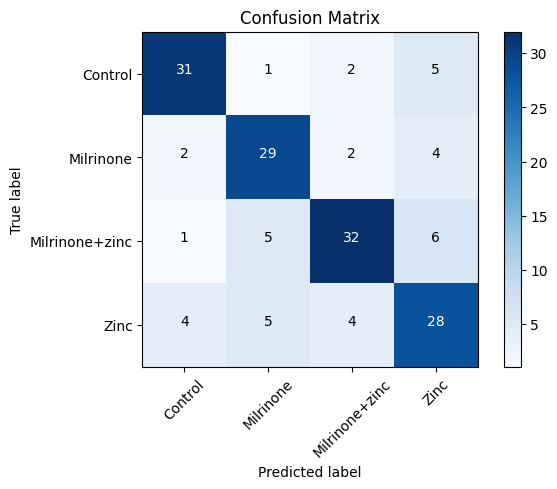

Accuracy Score: 0.7453416149068323
Precision Score: 0.7486861111322289
Recall Score: 0.7453416149068323
F1 Score: 0.7461482616762121
Classification Report:
                precision    recall  f1-score   support

       Control       0.82      0.79      0.81        39
     Milrinone       0.72      0.78      0.75        37
Milrinone+zinc       0.80      0.73      0.76        44
          Zinc       0.65      0.68      0.67        41

      accuracy                           0.75       161
     macro avg       0.75      0.75      0.75       161
  weighted avg       0.75      0.75      0.75       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.7453416149068323
Precision: 0.7479880660954712
Recall: 0.747213

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-04_2_0.jpg: 224x224 Control 0.99, Milrinone 0.01, Milrinone+zinc 0.00, Zinc 0.00, 20.8ms
Speed: 7.5ms preprocess, 20.8ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9904787540435791, 0.006797404959797859, 0.0019543319940567017, 0.0007694521336816251]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-05_0_2.jpg: 224x224 Control 1.00, Milrinone 0.00, Milrinone+zinc 0.00, Zinc 0.00, 18.9ms
Speed: 4.0ms preprocess, 18.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9950822591781616, 0.0020441324450075626, 0.001628486323170364, 0.001245182123966515]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib 100 Control 25.03.22 D025-05_2_2.jpg: 2

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9765911102294922, 7.287439075298607e-05, 0.022849662229418755, 0.00048640763270668685]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-05_2_0.jpg: 224x224 Control 0.95, Zinc 0.04, Milrinone+zinc 0.02, Milrinone 0.00, 18.3ms
Speed: 4.3ms preprocess, 18.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9453228712081909, 0.002505130600184202, 0.016264891251921654, 0.03590716794133186]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Control\Fib100 Control 20.01.22-07_1_2.jpg: 224x224 Control 0.98, Milrinone 0.01, Milrinone+zinc 0.01, Zinc 0.00, 18.7ms
Speed: 3.6ms preprocess, 18.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9827708005905151, 0.008811874315142632, 0.0064273914322257

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_0.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 18.9ms
Speed: 4.1ms preprocess, 18.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00030373260960914195, 0.9987167119979858, 0.000942191225476563, 3.7394664104795083e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_1.jpg: 224x224 Control 0.29, Milrinone 0.29, Zinc 0.26, Milrinone+zinc 0.16, 19.0ms
Speed: 4.2ms preprocess, 19.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.2947959005832672, 0.2861908972263336, 0.1608976125717163, 0.25811558961868286]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib 100 10uM Mil Post 30.11

Speed: 4.1ms preprocess, 19.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00030187476659193635, 0.9973331689834595, 0.002362295286729932, 2.781442844934645e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_2.jpg: 224x224 Milrinone 0.98, Control 0.02, Milrinone+zinc 0.00, Zinc 0.00, 19.7ms
Speed: 4.3ms preprocess, 19.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.017273617908358574, 0.9789144992828369, 0.0037712666671723127, 4.057093974552117e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_1.jpg: 224x224 Milrinone 0.84, Milrinone+zinc 0.16, Zinc 0.00, Control 0.00, 18.9ms
Speed: 4.2ms preprocess, 18.9ms inference, 1.1ms postprocess per image at shape (1, 3, 224, 224)
{0

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_0_2.jpg: 224x224 Zinc 0.61, Milrinone+zinc 0.39, Milrinone 0.00, Control 0.00, 17.7ms
Speed: 4.0ms preprocess, 17.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.2367238727838412e-07, 3.222604618713376e-06, 0.38635241985321045, 0.6136440634727478]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_0.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Control 0.00, Milrinone 0.00, 16.6ms
Speed: 5.1ms preprocess, 16.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.8580802134238183e-05, 6.834566192992497e-07, 0.9996228218078613, 0.0003578771138563752]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zi

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.8658041628659703e-05, 0.1019820049405098, 0.8968771696090698, 0.0011121603893116117]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_1_0.jpg: 224x224 Zinc 0.89, Milrinone+zinc 0.11, Control 0.00, Milrinone 0.00, 17.4ms
Speed: 4.1ms preprocess, 17.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.004381714854389429, 7.102912059053779e-05, 0.1056172102689743, 0.8899299502372742]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_2_2.jpg: 224x224 Milrinone+zinc 0.77, Zinc 0.21, Control 0.02, Milrinone 0.00, 17.8ms
Speed: 5.3ms preprocess, 17.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0013348172651603818, 0.000760665163397789, 0.018649965524673462, 0.9792545437812805]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100  Zinc 100uM 25.03.22 D025_2_2.jpg: 224x224 Zinc 0.90, Milrinone+zinc 0.10, Control 0.00, Milrinone 0.00, 21.4ms
Speed: 6.1ms preprocess, 21.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00102975161280483, 0.00023026319104246795, 0.10265959799289703, 0.8960803747177124]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_0_2.jpg: 224x224 Milrinone 0.53, Zinc 0.39, Control 0.05, Milrinone+zinc 0.03, 19.1ms
Speed: 4.9ms preprocess, 19.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.046967145055532455, 0.5268517732620239, 0.03283375501632690

Speed: 3.9ms preprocess, 20.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.5718598660896532e-05, 6.525849312311038e-05, 0.039325471967458725, 0.960593581199646]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-03_0_0.jpg: 224x224 Zinc 0.52, Milrinone+zinc 0.48, Control 0.00, Milrinone 0.00, 19.8ms
Speed: 4.7ms preprocess, 19.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00012674268509726971, 6.2454906583298e-05, 0.47802919149398804, 0.5217816233634949]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_2\test\Zinc\Fib 100 Zn2+ 19.01.21-03_2_2.jpg: 224x224 Zinc 0.58, Control 0.30, Milrinone+zinc 0.12, Milrinone 0.00, 19.0ms
Speed: 4.8ms preprocess, 19.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinon

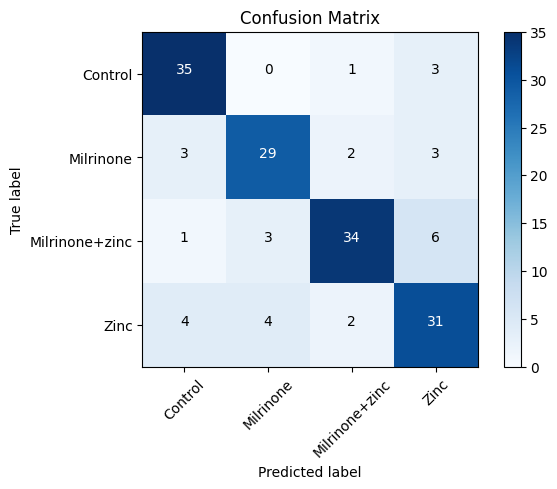

Accuracy Score: 0.8012422360248447
Precision Score: 0.8041419596020202
Recall Score: 0.8012422360248447
F1 Score: 0.8012424890297576
Classification Report:
                precision    recall  f1-score   support

       Control       0.81      0.90      0.85        39
     Milrinone       0.81      0.78      0.79        37
Milrinone+zinc       0.87      0.77      0.82        44
          Zinc       0.72      0.76      0.74        41

      accuracy                           0.80       161
     macro avg       0.80      0.80      0.80       161
  weighted avg       0.80      0.80      0.80       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8012422360248447
Precision: 0.803058537070165
Recall: 0.8025111

In [6]:
x = 1

names_model = 'Mcells-y11 without Augmentation '

data_folder = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2'

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

models = [YOLO('yolo11n-cls.pt'), YOLO('yolo11s-cls.pt'), YOLO('yolo11m-cls.pt'), YOLO('yolo11l-cls.pt'), YOLO('yolo11x-cls.pt')]
model_names = [' Yolov11 N', ' Yolov11 S', ' Yolov11 M', ' Yolov11 L', ' Yolov11 X']

paths = [fr"C:\Users\conso\Desktop\Yolo11\runs\classify\train{'' if i == 1 else i}\results.csv" for i in range(x, x+5)]

best_models = [fr"C:\Users\conso\Desktop\Yolo11\runs\classify\train{'' if i == 1 else i}\\weights\best.pt" for i in range(x, x+5)]
last_models = [fr"C:\Users\conso\Desktop\Yolo11\runs\classify\train{'' if i == 1 else i}\\weights\last.pt" for i in range(x, x+5)]

for mdel, model_name, path, best_model, last_model in zip(models, model_names, paths, best_models, last_models):
    model = mdel
    model.train(data= data_folder, epochs=30, imgsz=224) 

    print('-------------------------------')
    print(model_name)
    results_path = path

    name_model = names_model + best_model[-7:-3] +  model_name

    yolo_model_plot(results_path)


    # load a custom model
    print('Load Best Model')
    model = YOLO(best_model)

    # Get all the images in the test directory with the function
    actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

    # Plot the confusion matrix from the above
    conf_matrix = con_matrix_test(actual_image, predicted_image)

    # Get the test data metrics
    metrics_test(conf_matrix ,yolo_val_metrics = False)
    print('***********************************************************')

    # load a custom model
    print('Load Last Model')
    name_model = names_model + last_model[-7:-3] +  model_name
    model = YOLO(last_model)

    # Get all the images in the test directory with the function
    actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

    # Plot the confusion matrix from the above
    conf_matrix = con_matrix_test(actual_image, predicted_image)

    # Get the test data metrics
    metrics_test(conf_matrix ,yolo_val_metrics = False)
    print('***********************************************************') 

Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine\trainer: task=classify, mode=train, model=yolo11n-cls.pt, data=C:\Users\conso\Desktop\qq\Mcells\Completed_3, epochs=30, time=None, patience=100, batch=16, imgsz=224, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train6, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=Fa

train: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_3\train... 4174 images, 0 corrupt: 100%|██████████| 4174/417
val: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_3\val... 314 images, 0 corrupt: 100%|██████████| 314/314 [00:0


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\train6
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 35.57it/s]

                   all      0.522          1


...

      30/30      0.34G     0.4333         14        224: 100%|██████████| 261/261 [00:18<00:00, 13.82it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 28.13it/s]

                   all      0.828          1



30 epochs completed in 0.267 hours.
Optimizer stripped from runs\classify\train6\weights\last.pt, 3.2MB
Optimizer stripped from runs\classify\train6\weights\best.pt, 3.2MB

Validating runs\classify\train6\weights\best.pt...
Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11n-cls summary (fused): 112 layers, 1,531,148 parameters, 0 gradients, 3.2 GFLOPs
train: C:\Users\conso\Desktop\qq\Mcells\Completed_3\train... found 4174 images in 4 classes  
val: C:\Users\conso\Desktop\qq\Mcells\Completed_3\val... found 314 images in 4 classes  
test: C:\Users\conso\Desktop\qq\Mcells\Completed_3\test... found 161 images in 4 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 21.66it/s]


                   all      0.857          1
Speed: 0.5ms preprocess, 0.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train6
-------------------------------
 Yolov11 N


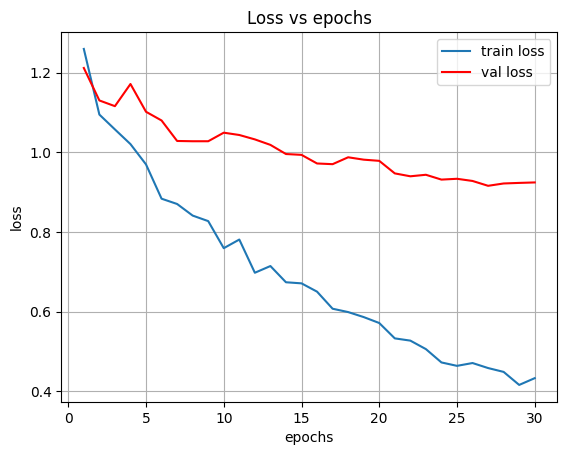

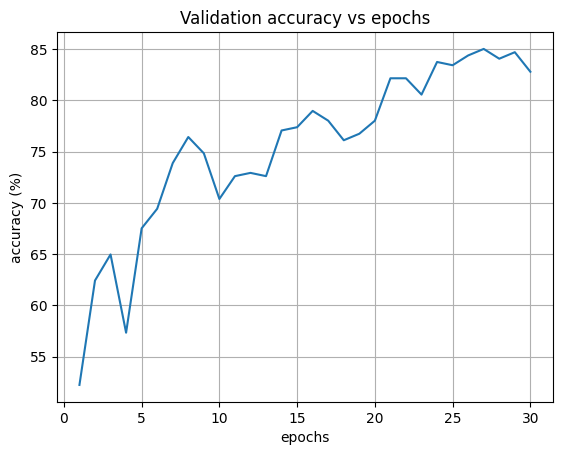

Load Best Model
Get the images from test directory for prediction

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 15.03.22 -02_1_0.jpg: 224x224 Control 0.69, Zinc 0.26, Milrinone 0.03, Milrinone+zinc 0.01, 4.7ms
Speed: 6.0ms preprocess, 4.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.6949281096458435, 0.031435344368219376, 0.008948730304837227, 0.26468780636787415]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 15.03.22 -03_1_0.jpg: 224x224 Zinc 0.61, Control 0.39, Milrinone+zinc 0.00, Milrinone 0.00, 16.0ms
Speed: 2.9ms preprocess, 16.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.39077046513557434, 3.731783726834692e-05, 0.0004885740345343947, 0.6087037324905396]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999921321868896, 2.6227709781778685e-07, 4.5206443033407595e-09, 7.623134024470346e-06]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.05.22 D004-02_1_2.jpg: 224x224 Control 1.00, Milrinone 0.00, Zinc 0.00, Milrinone+zinc 0.00, 14.7ms
Speed: 6.2ms preprocess, 14.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9998366832733154, 8.652905671624467e-05, 2.262471753056161e-05, 5.4064341384219006e-05]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.05.22 D004-02_2_1.jpg: 224x224 Control 0.83, Milrinone 0.16, Milrinone+zinc 0.00, Zinc 0.00, 10.5ms
Speed: 5.5ms preprocess, 10.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8344824910163879, 0.16488948464393616, 

Speed: 5.7ms preprocess, 12.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999679327011108, 1.376620684112595e-08, 2.8674377972492948e-05, 3.3029052701749606e-06]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22_0_1.jpg: 224x224 Control 0.94, Milrinone+zinc 0.05, Zinc 0.01, Milrinone 0.00, 11.2ms
Speed: 4.7ms preprocess, 11.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9405616521835327, 0.002239306690171361, 0.051572758704423904, 0.005626235157251358]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100  10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Control 0.54, Milrinone 0.31, Zinc 0.10, Milrinone+zinc 0.05, 12.3ms
Speed: 5.5ms preprocess, 12.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Contro

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.005584954749792814, 0.3991334140300751, 0.03592948988080025, 0.5593520998954773]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_0_2.jpg: 224x224 Milrinone 0.71, Zinc 0.14, Control 0.13, Milrinone+zinc 0.01, 13.4ms
Speed: 6.2ms preprocess, 13.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.13310091197490692, 0.7077711224555969, 0.014487138018012047, 0.14464090764522552]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_2_2.jpg: 224x224 Zinc 0.87, Milrinone 0.06, Milrinone+zinc 0.05, Control 0.02, 13.7ms
Speed: 5.2ms preprocess, 13.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.01664232648909092, 0.060692619532346725, 0.0

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Zinc 0.00, Control 0.00, 8.5ms
Speed: 5.8ms preprocess, 8.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.2997692238059244e-06, 0.99998939037323, 5.7389702305954415e-06, 3.520186965033645e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_2_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 12.9ms
Speed: 7.9ms preprocess, 12.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.8918555472046137e-05, 0.9999368190765381, 2.9598637411254458e-05, 4.666261247621151e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100  Zinc+ 10uM Mil

Speed: 5.4ms preprocess, 14.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0027644645888358355, 0.0003502516483422369, 0.04362276941537857, 0.9532625079154968]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_2_0.jpg: 224x224 Milrinone+zinc 0.99, Control 0.01, Zinc 0.00, Milrinone 0.00, 14.0ms
Speed: 5.1ms preprocess, 14.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.010237259790301323, 1.8859778720070608e-05, 0.9876015782356262, 0.0021423192229121923]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-05_0_2.jpg: 224x224 Milrinone+zinc 0.65, Zinc 0.34, Control 0.01, Milrinone 0.00, 11.6ms
Speed: 5.5ms preprocess, 11.6ms inference, 0.0ms postprocess per image at 

Speed: 5.2ms preprocess, 11.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.05351654440164566, 0.000602707383222878, 0.07435709238052368, 0.8715236783027649]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_0.jpg: 224x224 Milrinone+zinc 1.00, Milrinone 0.00, Zinc 0.00, Control 0.00, 13.2ms
Speed: 5.9ms preprocess, 13.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0003414720413275063, 0.0015266252448782325, 0.9970734119415283, 0.001058465801179409]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_2.jpg: 224x224 Milrinone+zinc 0.98, Control 0.01, Milrinone 0.00, Zinc 0.00, 16.5ms
Speed: 2.4ms preprocess, 16.5ms inference, 0.0ms postprocess p

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.05024401843547821, 0.029208268970251083, 3.214537355233915e-05, 0.9205155968666077]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -03_1_0.jpg: 224x224 Zinc 0.96, Control 0.04, Milrinone 0.00, Milrinone+zinc 0.00, 17.2ms
Speed: 1.9ms preprocess, 17.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.03700786083936691, 0.0010230651823803782, 0.00013035548909101635, 0.9618387222290039]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -04_2_2.jpg: 224x224 Milrinone 0.95, Zinc 0.05, Milrinone+zinc 0.00, Control 0.00, 11.7ms
Speed: 6.0ms preprocess, 11.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0034728634636849165, 0.945905327796936, 0.004420694429427385

Speed: 5.0ms preprocess, 13.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.756597677944228e-05, 0.003788309171795845, 0.4733116924762726, 0.5228724479675293]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_2.jpg: 224x224 Zinc 0.89, Milrinone+zinc 0.11, Control 0.00, Milrinone 0.00, 16.2ms
Speed: 3.3ms preprocess, 16.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.810379318267223e-07, 2.226189508292009e-07, 0.10752017796039581, 0.8924790024757385]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21_0_2.jpg: 224x224 Zinc 0.93, Milrinone+zinc 0.06, Milrinone 0.01, Control 0.00, 9.6ms
Speed: 7.0ms preprocess, 9.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc'

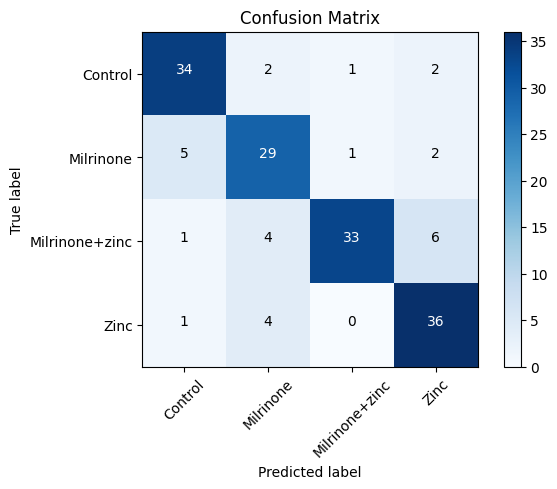

Accuracy Score: 0.8198757763975155
Precision Score: 0.8287388492851433
Recall Score: 0.8198757763975155
F1 Score: 0.8203563370118502
Classification Report:
                precision    recall  f1-score   support

       Control       0.83      0.87      0.85        39
     Milrinone       0.74      0.78      0.76        37
Milrinone+zinc       0.94      0.75      0.84        44
          Zinc       0.78      0.88      0.83        41

      accuracy                           0.82       161
     macro avg       0.82      0.82      0.82       161
  weighted avg       0.83      0.82      0.82       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8198757763975155
Precision: 0.8245809686954968
Recall: 0.820906

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-04_2_0.jpg: 224x224 Control 0.84, Zinc 0.15, Milrinone 0.01, Milrinone+zinc 0.00, 13.3ms
Speed: 4.9ms preprocess, 13.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8361501693725586, 0.012214099988341331, 4.8856742068892345e-05, 0.15158692002296448]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-05_0_2.jpg: 224x224 Control 0.48, Zinc 0.47, Milrinone 0.04, Milrinone+zinc 0.00, 15.7ms
Speed: 2.9ms preprocess, 15.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.4818527400493622, 0.04490429908037186, 0.00020000667427666485, 0.47304296493530273]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-05_2_2.jpg: 224

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999417066574097, 2.8211235303388094e-07, 5.7823301176540554e-05, 2.4873975235095713e-07]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-05_2_0.jpg: 224x224 Control 0.97, Zinc 0.02, Milrinone+zinc 0.01, Milrinone 0.00, 21.6ms
Speed: 6.5ms preprocess, 21.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.974855363368988, 4.701470572854305e-07, 0.0094955088570714, 0.015648633241653442]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-07_1_2.jpg: 224x224 Control 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Zinc 0.00, 12.6ms
Speed: 4.2ms preprocess, 12.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9978188276290894, 0.00019889199757017195, 0.001828267122

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_0.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Zinc 0.00, Control 0.00, 13.3ms
Speed: 5.1ms preprocess, 13.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.484596577938646e-05, 0.9996007084846497, 0.0003401845460757613, 4.438641553861089e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_1.jpg: 224x224 Control 0.53, Zinc 0.19, Milrinone 0.14, Milrinone+zinc 0.14, 13.4ms
Speed: 5.6ms preprocess, 13.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.5294560790061951, 0.14442160725593567, 0.13809870183467865, 0.18802358210086823]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.1

Speed: 6.1ms preprocess, 12.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.050007227831884e-07, 0.9999991655349731, 3.998094371127081e-07, 4.0406732182418637e-07]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 12.5ms
Speed: 5.2ms preprocess, 12.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0009658756898716092, 0.9974445104598999, 0.0012046602787449956, 0.0003850420762319118]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_1.jpg: 224x224 Milrinone 1.00, Zinc 0.00, Milrinone+zinc 0.00, Control 0.00, 14.3ms
Speed: 7.2ms preprocess, 14.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)


image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_0_2.jpg: 224x224 Milrinone+zinc 0.61, Zinc 0.39, Milrinone 0.00, Control 0.00, 12.3ms
Speed: 5.3ms preprocess, 12.3ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.37867851764895e-05, 9.235090692527592e-05, 0.6075223684310913, 0.39232149720191956]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Zinc 0.00, Milrinone 0.00, 13.2ms
Speed: 6.0ms preprocess, 13.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0011213462566956878, 3.943208355394745e-07, 0.9988490343093872, 2.9242832169984467e-05]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milr

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.000124576676171273, 0.013777513056993484, 0.9803010821342468, 0.005796821787953377]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_1_0.jpg: 224x224 Zinc 0.95, Milrinone+zinc 0.04, Control 0.01, Milrinone 0.00, 10.2ms
Speed: 6.0ms preprocess, 10.2ms inference, 0.2ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.005855728406459093, 0.00014169221685733646, 0.03992404043674469, 0.9540785551071167]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_2_2.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Control 0.00, Milrinone 0.00, 11.4ms
Speed: 7.6ms preprocess, 11.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[4.7603512030036654e-06, 1.684548806224484e-05, 0.00020850209693890065, 0.9997699856758118]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100  Zinc 100uM 25.03.22 D025_2_2.jpg: 224x224 Zinc 0.96, Milrinone+zinc 0.02, Control 0.02, Milrinone 0.00, 14.9ms
Speed: 3.5ms preprocess, 14.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.01670783944427967, 0.0002881046966649592, 0.018454352393746376, 0.9645496010780334]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_0_2.jpg: 224x224 Zinc 1.00, Milrinone 0.00, Control 0.00, Milrinone+zinc 0.00, 14.3ms
Speed: 6.5ms preprocess, 14.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00047689967323094606, 0.0011834606993943453, 1.06714905

Speed: 6.5ms preprocess, 12.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.2664337191381492e-05, 0.0002885563881136477, 0.0019970026332885027, 0.9977018237113953]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-03_0_0.jpg: 224x224 Zinc 1.00, Milrinone+zinc 0.00, Control 0.00, Milrinone 0.00, 12.1ms
Speed: 6.2ms preprocess, 12.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.219771039728812e-08, 1.1472990557592766e-08, 0.0017896498320624232, 0.9982103109359741]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-03_2_2.jpg: 224x224 Milrinone+zinc 0.58, Zinc 0.41, Milrinone 0.00, Control 0.00, 11.0ms
Speed: 6.1ms preprocess, 11.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Mi

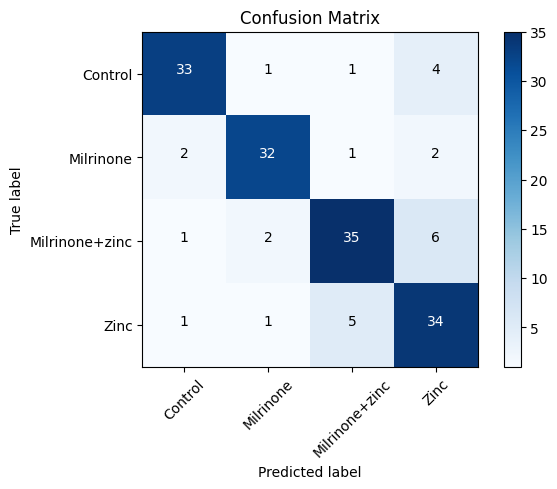

Accuracy Score: 0.8322981366459627
Precision Score: 0.8362961935740764
Recall Score: 0.8322981366459627
F1 Score: 0.8333335883036116
Classification Report:
                precision    recall  f1-score   support

       Control       0.89      0.85      0.87        39
     Milrinone       0.89      0.86      0.88        37
Milrinone+zinc       0.83      0.80      0.81        44
          Zinc       0.74      0.83      0.78        41

      accuracy                           0.83       161
     macro avg       0.84      0.83      0.84       161
  weighted avg       0.84      0.83      0.83       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8322981366459627
Precision: 0.8383111372241807
Recall: 0.833935

train: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_3\train... 4174 images, 0 corrupt: 100%|██████████| 4174/417
val: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_3\val... 314 images, 0 corrupt: 100%|██████████| 314/314 [00:0


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 39 weight(decay=0.0), 40 weight(decay=0.0005), 40 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\train7
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 38.35it/s]

                   all      0.596          1


...

      30/30     0.547G     0.3791         14        224: 100%|██████████| 261/261 [00:20<00:00, 12.62it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 26.23it/s]

                   all      0.841          1



30 epochs completed in 0.199 hours.
Optimizer stripped from runs\classify\train7\weights\last.pt, 11.0MB
Optimizer stripped from runs\classify\train7\weights\best.pt, 11.0MB

Validating runs\classify\train7\weights\best.pt...
Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11s-cls summary (fused): 112 layers, 5,439,252 parameters, 0 gradients, 12.0 GFLOPs
train: C:\Users\conso\Desktop\qq\Mcells\Completed_3\train... found 4174 images in 4 classes  
val: C:\Users\conso\Desktop\qq\Mcells\Completed_3\val... found 314 images in 4 classes  
test: C:\Users\conso\Desktop\qq\Mcells\Completed_3\test... found 161 images in 4 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 31.67it/s]


                   all      0.841          1
Speed: 0.2ms preprocess, 0.7ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train7
-------------------------------
 Yolov11 S


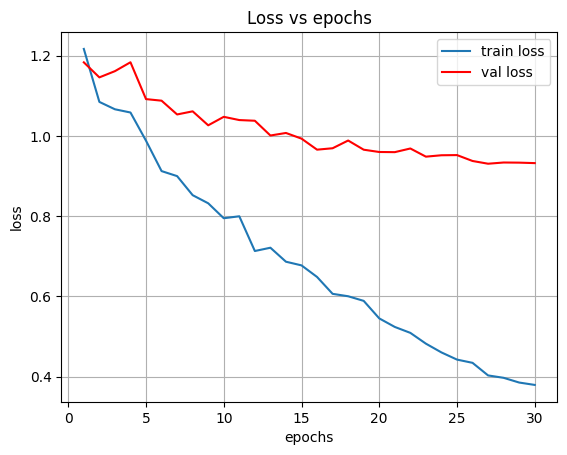

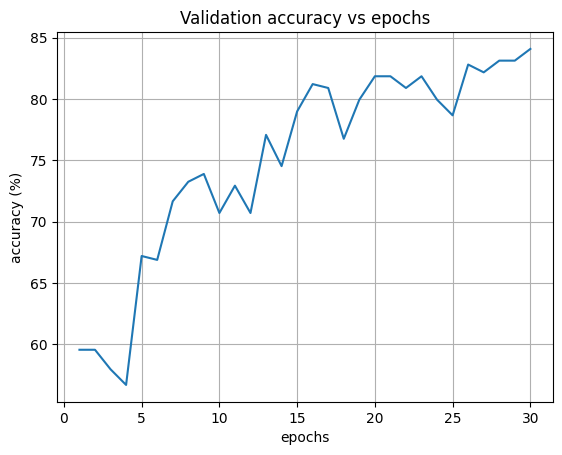

Load Best Model
Get the images from test directory for prediction

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 15.03.22 -02_1_0.jpg: 224x224 Zinc 0.60, Control 0.38, Milrinone 0.02, Milrinone+zinc 0.00, 12.0ms
Speed: 4.9ms preprocess, 12.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.3815399408340454, 0.0186428502202034, 0.0006593951839022338, 0.5991578102111816]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 15.03.22 -03_1_0.jpg: 224x224 Control 0.53, Zinc 0.47, Milrinone+zinc 0.00, Milrinone 0.00, 15.6ms
Speed: 3.7ms preprocess, 15.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.5322880744934082, 0.0003166797396261245, 0.0016844995552673936, 0.46571069955825806]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999806880950928, 1.8843091311282478e-05, 3.8958722825555014e-07, 8.910927107308453e-08]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.05.22 D004-02_1_2.jpg: 224x224 Control 1.00, Zinc 0.00, Milrinone 0.00, Milrinone+zinc 0.00, 20.3ms
Speed: 6.8ms preprocess, 20.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9996453523635864, 0.00014192832168191671, 2.7253667212789878e-05, 0.00018537617870606482]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.05.22 D004-02_2_1.jpg: 224x224 Control 0.99, Milrinone 0.00, Milrinone+zinc 0.00, Zinc 0.00, 20.6ms
Speed: 6.2ms preprocess, 20.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9947212934494019, 0.00498290685936808

Speed: 6.3ms preprocess, 16.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999955892562866, 3.163019357543817e-07, 3.992911388195353e-06, 2.0499687991559767e-07]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22_0_1.jpg: 224x224 Control 0.85, Zinc 0.11, Milrinone 0.03, Milrinone+zinc 0.00, 16.3ms
Speed: 5.4ms preprocess, 16.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8538395166397095, 0.033964917063713074, 0.004812062717974186, 0.10738349705934525]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100  10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone 0.98, Zinc 0.01, Milrinone+zinc 0.01, Control 0.00, 14.8ms
Speed: 6.7ms preprocess, 14.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control'

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.001998750027269125, 0.9884364604949951, 0.007449882570654154, 0.002114945789799094]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_0_2.jpg: 224x224 Milrinone 0.89, Milrinone+zinc 0.06, Control 0.03, Zinc 0.02, 16.1ms
Speed: 7.0ms preprocess, 16.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.025997720658779144, 0.8902508616447449, 0.06271473318338394, 0.02103661559522152]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_2_2.jpg: 224x224 Milrinone+zinc 0.74, Control 0.14, Zinc 0.11, Milrinone 0.02, 10.2ms
Speed: 5.3ms preprocess, 10.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.13623054325580597, 0.016968924552202

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.121550980722532e-05, 0.9953142404556274, 0.003996036481112242, 0.000658539473079145]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Zinc 0.00, Control 0.00, 19.9ms
Speed: 11.6ms preprocess, 19.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.1529059424096886e-08, 0.9999845027923584, 1.4079523680265993e-05, 1.4619383819081122e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_2_2.jpg: 224x224 Milrinone 1.00, Control 0.00, Milrinone+zinc 0.00, Zinc 0.00, 10.2ms
Speed: 6.0ms preprocess, 10.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00019168833387084305, 0.999751

Speed: 1.7ms preprocess, 12.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[9.394278458785266e-05, 2.2330203819365124e-07, 0.002746921731159091, 0.9971588850021362]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_2_0.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Control 0.00, Milrinone 0.00, 9.6ms
Speed: 4.1ms preprocess, 9.6ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00010753697279142216, 3.95105507777771e-06, 0.9996390342712402, 0.0002494986110832542]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-05_0_2.jpg: 224x224 Zinc 0.84, Milrinone+zinc 0.16, Control 0.00, Milrinone 0.00, 11.6ms
Speed: 4.9ms preprocess, 11.6ms inference, 0.6ms postprocess per image at 

Speed: 5.1ms preprocess, 10.2ms inference, 1.1ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.003214095951989293, 0.0008312778663821518, 0.012117085047066212, 0.9838375449180603]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Milrinone 0.00, Zinc 0.00, 10.0ms
Speed: 4.4ms preprocess, 10.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00013268348993733525, 6.473856774391606e-05, 0.9997993111610413, 3.3570024697837653e-06]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_2.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Milrinone 0.00, Zinc 0.00, 9.3ms
Speed: 4.6ms preprocess, 9.3ms inference, 0.0ms postproce

Speed: 5.7ms preprocess, 9.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00014986982569098473, 1.3513364137907047e-05, 3.918359414711858e-09, 0.9998366832733154]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -03_1_0.jpg: 224x224 Zinc 0.99, Milrinone 0.01, Control 0.00, Milrinone+zinc 0.00, 9.2ms
Speed: 5.3ms preprocess, 9.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.2723262443614658e-05, 0.006953609175980091, 7.490551752198371e-07, 0.9930329322814941]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -04_2_2.jpg: 224x224 Milrinone 0.97, Zinc 0.02, Control 0.01, Milrinone+zinc 0.00, 9.3ms
Speed: 4.3ms preprocess, 9.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone

Speed: 4.1ms preprocess, 18.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.5953995898598805e-05, 7.685331365792081e-05, 0.7487925291061401, 0.2511146366596222]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_2.jpg: 224x224 Zinc 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Control 0.00, 18.0ms
Speed: 6.2ms preprocess, 18.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.809528171747843e-08, 1.2667739213156892e-07, 0.001388226868584752, 0.998611569404602]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21_0_2.jpg: 224x224 Zinc 0.51, Milrinone+zinc 0.48, Milrinone 0.01, Control 0.00, 18.3ms
Speed: 6.5ms preprocess, 18.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: '

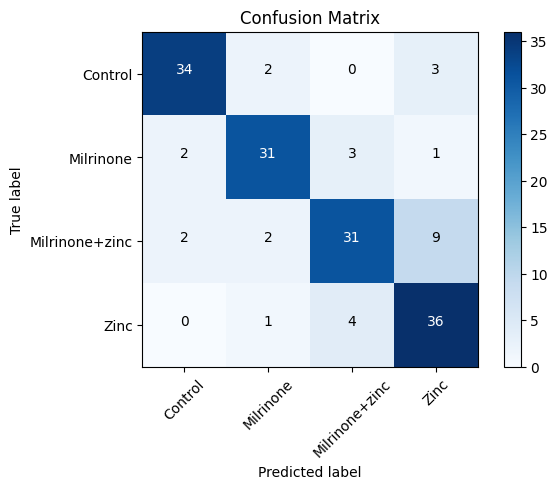

Accuracy Score: 0.8198757763975155
Precision Score: 0.8246772284156116
Recall Score: 0.8198757763975155
F1 Score: 0.8194689978803221
Classification Report:
                precision    recall  f1-score   support

       Control       0.89      0.87      0.88        39
     Milrinone       0.86      0.84      0.85        37
Milrinone+zinc       0.82      0.70      0.76        44
          Zinc       0.73      0.88      0.80        41

      accuracy                           0.82       161
     macro avg       0.83      0.82      0.82       161
  weighted avg       0.82      0.82      0.82       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8198757763975155
Precision: 0.8265828261129013
Recall: 0.823056

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-04_2_0.jpg: 224x224 Control 1.00, Zinc 0.00, Milrinone 0.00, Milrinone+zinc 0.00, 16.5ms
Speed: 5.3ms preprocess, 16.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9979810118675232, 0.0008129781344905496, 1.218218676513061e-05, 0.0011938767274841666]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-05_0_2.jpg: 224x224 Control 0.89, Milrinone 0.11, Zinc 0.00, Milrinone+zinc 0.00, 15.1ms
Speed: 6.0ms preprocess, 15.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.892809271812439, 0.1055421531200409, 5.762232467532158e-05, 0.001591059728525579]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-05_2_2.jpg: 224

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9996367692947388, 2.722438807722938e-07, 0.0003588202234823257, 4.153320332989097e-06]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-05_2_0.jpg: 224x224 Control 1.00, Zinc 0.00, Milrinone+zinc 0.00, Milrinone 0.00, 10.2ms
Speed: 4.3ms preprocess, 10.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.995098888874054, 7.948913662403356e-06, 0.0003722304536495358, 0.004520923364907503]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-07_1_2.jpg: 224x224 Control 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Zinc 0.00, 10.2ms
Speed: 4.2ms preprocess, 10.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.998908519744873, 4.554224869934842e-05, 0.00103010027669

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_0.jpg: 224x224 Milrinone 1.00, Zinc 0.00, Milrinone+zinc 0.00, Control 0.00, 25.0ms
Speed: 6.2ms preprocess, 25.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[9.510763447906356e-06, 0.9998123049736023, 3.4727239835774526e-05, 0.00014353821461554617]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_1.jpg: 224x224 Milrinone 0.95, Control 0.03, Zinc 0.01, Milrinone+zinc 0.01, 10.2ms
Speed: 4.6ms preprocess, 10.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.026939500123262405, 0.95329350233078, 0.007529263850301504, 0.01223774068057537]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_0.jpg: 224x224 Milrinone 1.00, Zinc 0.00, Milrinone+zinc 0.00, Control 0.00, 25.2ms
Speed: 5.3ms preprocess, 25.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.5454703827799676e-07, 0.9999966621398926, 1.241624431713717e-06, 1.913552296173293e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_2.jpg: 224x224 Milrinone 1.00, Control 0.00, Milrinone+zinc 0.00, Zinc 0.00, 21.8ms
Speed: 8.5ms preprocess, 21.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0006461921148002148, 0.9990478157997131, 0.000215871274122037, 9.016403782879934e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0005241767503321171, 0.00011372332664905116, 0.00327179953455925, 0.9960902333259583]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_0_2.jpg: 224x224 Milrinone+zinc 0.52, Zinc 0.48, Control 0.00, Milrinone 0.00, 18.4ms
Speed: 5.0ms preprocess, 18.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.08923699776642e-05, 6.18707645116956e-06, 0.518290638923645, 0.4816722571849823]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_0.jpg: 224x224 Milrinone+zinc 0.98, Control 0.01, Zinc 0.01, Milrinone 0.00, 18.1ms
Speed: 9.1ms preprocess, 18.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0145691521465

Speed: 7.1ms preprocess, 11.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.006870263256132603, 0.006844667252153158, 0.9762780070304871, 0.010007182136178017]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_1_0.jpg: 224x224 Control 0.74, Zinc 0.24, Milrinone+zinc 0.02, Milrinone 0.00, 11.9ms
Speed: 3.3ms preprocess, 11.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.7353512048721313, 5.60247317480389e-05, 0.0247164536267519, 0.23987628519535065]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_2_2.jpg: 224x224 Milrinone+zinc 0.98, Control 0.01, Zinc 0.00, Milrinone 0.00, 10.6ms
Speed: 4.0ms preprocess, 10.6ms inference, 0.0ms postprocess p

Speed: 4.3ms preprocess, 16.4ms inference, 0.2ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00014449669106397778, 6.575373117811978e-05, 0.001260609133169055, 0.9985291957855225]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100  Zinc 100uM 25.03.22 D025_2_2.jpg: 224x224 Zinc 1.00, Milrinone+zinc 0.00, Control 0.00, Milrinone 0.00, 16.3ms
Speed: 4.9ms preprocess, 16.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[5.445650458568707e-06, 1.5051726904857787e-06, 3.407493932172656e-05, 0.999958872795105]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_0_2.jpg: 224x224 Zinc 0.93, Milrinone 0.07, Control 0.00, Milrinone+zinc 0.00, 16.3ms
Speed: 6.1ms preprocess, 16.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milr

Speed: 10.4ms preprocess, 17.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[7.077612735884031e-07, 7.313868081837427e-06, 6.703452072542859e-06, 0.9999853372573853]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-03_0_0.jpg: 224x224 Zinc 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Control 0.00, 14.7ms
Speed: 7.5ms preprocess, 14.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.6431807303707302e-10, 1.3259462416925771e-09, 0.0007419795147143304, 0.9992579817771912]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-03_2_2.jpg: 224x224 Milrinone+zinc 0.86, Zinc 0.12, Control 0.03, Milrinone 0.00, 12.6ms
Speed: 7.9ms preprocess, 12.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'M

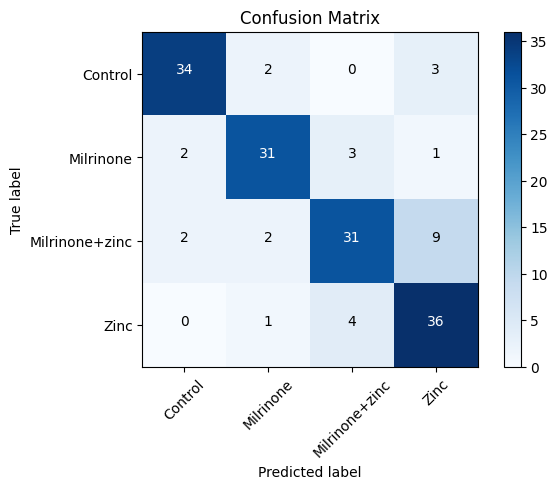

Accuracy Score: 0.8198757763975155
Precision Score: 0.8246772284156116
Recall Score: 0.8198757763975155
F1 Score: 0.8194689978803221
Classification Report:
                precision    recall  f1-score   support

       Control       0.89      0.87      0.88        39
     Milrinone       0.86      0.84      0.85        37
Milrinone+zinc       0.82      0.70      0.76        44
          Zinc       0.73      0.88      0.80        41

      accuracy                           0.82       161
     macro avg       0.83      0.82      0.82       161
  weighted avg       0.82      0.82      0.82       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8198757763975155
Precision: 0.8265828261129013
Recall: 0.823056

train: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_3\train... 4174 images, 0 corrupt: 100%|██████████| 4174/417
val: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_3\val... 314 images, 0 corrupt: 100%|██████████| 314/314 [00:0


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 49 weight(decay=0.0), 50 weight(decay=0.0005), 50 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\train8
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 28.80it/s]

                   all      0.586          1


...

      30/30      1.16G     0.3316         14        224: 100%|██████████| 261/261 [00:25<00:00, 10.24it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 33.70it/s]

                   all      0.841          1



30 epochs completed in 0.224 hours.
Optimizer stripped from runs\classify\train8\weights\last.pt, 20.9MB
Optimizer stripped from runs\classify\train8\weights\best.pt, 20.9MB

Validating runs\classify\train8\weights\best.pt...
Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11m-cls summary (fused): 138 layers, 10,346,756 parameters, 0 gradients, 39.3 GFLOPs
train: C:\Users\conso\Desktop\qq\Mcells\Completed_3\train... found 4174 images in 4 classes  
val: C:\Users\conso\Desktop\qq\Mcells\Completed_3\val... found 314 images in 4 classes  
test: C:\Users\conso\Desktop\qq\Mcells\Completed_3\test... found 161 images in 4 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 26.25it/s]


                   all      0.854          1
Speed: 0.2ms preprocess, 0.9ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train8
-------------------------------
 Yolov11 M


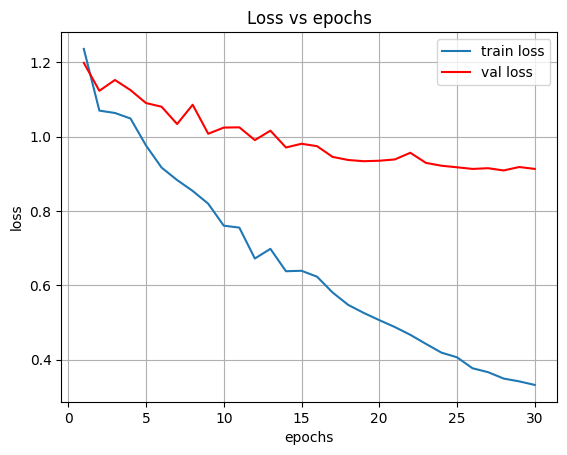

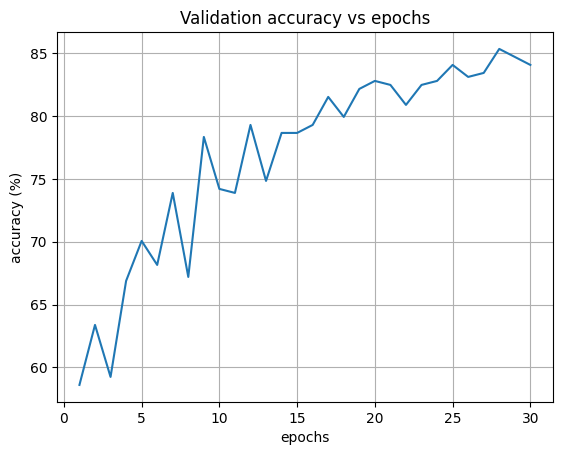

Load Best Model
Get the images from test directory for prediction

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 15.03.22 -02_1_0.jpg: 224x224 Control 0.96, Zinc 0.03, Milrinone 0.00, Milrinone+zinc 0.00, 11.7ms
Speed: 5.1ms preprocess, 11.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9645603895187378, 0.002830984303727746, 7.057465700199828e-05, 0.03253805264830589]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 15.03.22 -03_1_0.jpg: 224x224 Control 0.71, Zinc 0.28, Milrinone+zinc 0.01, Milrinone 0.00, 9.5ms
Speed: 3.7ms preprocess, 9.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.7107220888137817, 0.0001064647440216504, 0.007993794046342373, 0.28117769956588745]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\te

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.0, 5.349099496676502e-10, 2.81309333466373e-11, 9.943375333179572e-13]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.05.22 D004-02_1_2.jpg: 224x224 Control 1.00, Milrinone 0.00, Milrinone+zinc 0.00, Zinc 0.00, 12.0ms
Speed: 5.2ms preprocess, 12.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9998167157173157, 0.0001499384525232017, 2.3224882170325145e-05, 1.0130091141036246e-05]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.05.22 D004-02_2_1.jpg: 224x224 Control 0.99, Milrinone 0.01, Milrinone+zinc 0.00, Zinc 0.00, 12.2ms
Speed: 5.2ms preprocess, 12.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9935913681983948, 0.0058633326552808285, 0.0005432768957

Speed: 14.1ms preprocess, 32.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999872446060181, 1.6111874856505892e-07, 1.0949718671326991e-05, 1.6801500350993592e-06]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22_0_1.jpg: 224x224 Control 0.88, Zinc 0.07, Milrinone 0.05, Milrinone+zinc 0.00, 35.9ms
Speed: 11.0ms preprocess, 35.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.882353663444519, 0.04520326852798462, 0.00305307749658823, 0.06938993185758591]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100  10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone 0.87, Zinc 0.06, Milrinone+zinc 0.06, Control 0.01, 24.0ms
Speed: 10.7ms preprocess, 24.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Contro

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.016527967527508736, 0.9819996356964111, 0.00024663953809067607, 0.0012257266789674759]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_0_2.jpg: 224x224 Milrinone 0.98, Zinc 0.01, Milrinone+zinc 0.00, Control 0.00, 10.3ms
Speed: 4.1ms preprocess, 10.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.003045513527467847, 0.9842586517333984, 0.004123822320252657, 0.008571983315050602]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_2_2.jpg: 224x224 Zinc 0.50, Milrinone 0.39, Control 0.09, Milrinone+zinc 0.01, 12.6ms
Speed: 4.4ms preprocess, 12.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.09477435052394867, 0.3913968205

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Zinc 0.00, Control 0.00, 15.4ms
Speed: 5.4ms preprocess, 15.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.2235193430096842e-06, 0.999157190322876, 0.0008314014412462711, 8.231615538534243e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_2_2.jpg: 224x224 Milrinone 0.99, Milrinone+zinc 0.01, Control 0.00, Zinc 0.00, 15.3ms
Speed: 5.1ms preprocess, 15.3ms inference, 1.1ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.89758817316033e-05, 0.9947505593299866, 0.0051789418794214725, 1.495872879786475e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100  Zinc+ 10uM Milr

Speed: 4.2ms preprocess, 14.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[5.932492058491334e-05, 2.386599646797549e-07, 0.0012918456923216581, 0.9986485838890076]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_2_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Zinc 0.00, Milrinone 0.00, 13.5ms
Speed: 5.4ms preprocess, 13.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0006429944187402725, 5.118156991557044e-07, 0.9992094039916992, 0.00014711775293108076]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-05_0_2.jpg: 224x224 Zinc 0.70, Milrinone+zinc 0.30, Control 0.00, Milrinone 0.00, 32.1ms
Speed: 11.6ms preprocess, 32.1ms inference, 0.0ms postprocess per image

Speed: 4.9ms preprocess, 13.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[8.748414984438568e-05, 5.3585459681926295e-05, 0.012058212421834469, 0.9878007173538208]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Milrinone 0.00, Zinc 0.00, 32.9ms
Speed: 12.1ms preprocess, 32.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0010156758362427354, 4.908958726446144e-05, 0.9989305138587952, 4.791304945683805e-06]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_2.jpg: 224x224 Milrinone+zinc 0.98, Control 0.02, Milrinone 0.00, Zinc 0.00, 26.4ms
Speed: 5.4ms preprocess, 26.4ms inference, 0.0ms postpr

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.02060534618794918, 0.7504992485046387, 4.946966510033235e-05, 0.22884584963321686]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -03_1_0.jpg: 224x224 Zinc 0.86, Milrinone 0.11, Control 0.03, Milrinone+zinc 0.00, 14.4ms
Speed: 5.9ms preprocess, 14.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.027387717738747597, 0.11157224327325821, 0.0008541823481209576, 0.8601859211921692]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -04_2_2.jpg: 224x224 Control 0.42, Milrinone 0.37, Zinc 0.21, Milrinone+zinc 0.00, 15.7ms
Speed: 5.3ms preprocess, 15.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.41561901569366455, 0.37086400389671326, 0.0032397748436778

Speed: 5.7ms preprocess, 12.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[5.022197001380846e-06, 5.481205789692467e-06, 0.18593861162662506, 0.8140509128570557]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_2.jpg: 224x224 Zinc 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Control 0.00, 12.8ms
Speed: 5.6ms preprocess, 12.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.7798821971837242e-08, 6.140795960618561e-08, 0.00015455026004929096, 0.9998452663421631]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21_0_2.jpg: 224x224 Zinc 0.99, Milrinone+zinc 0.01, Milrinone 0.00, Control 0.00, 12.5ms
Speed: 5.3ms preprocess, 12.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrino

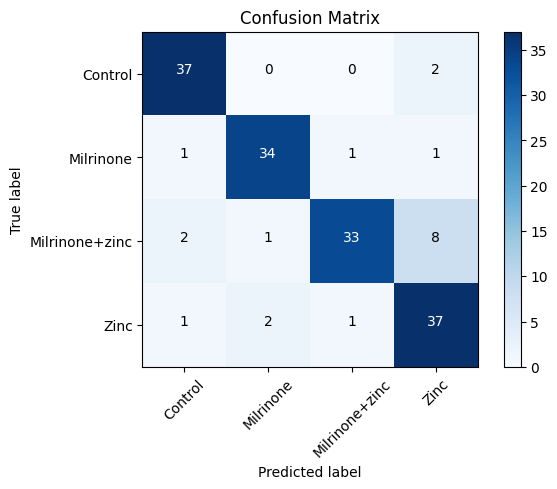

Accuracy Score: 0.8757763975155279
Precision Score: 0.8837577820099407
Recall Score: 0.8757763975155279
F1 Score: 0.8753067162194752
Classification Report:
                precision    recall  f1-score   support

       Control       0.90      0.95      0.92        39
     Milrinone       0.92      0.92      0.92        37
Milrinone+zinc       0.94      0.75      0.84        44
          Zinc       0.77      0.90      0.83        41

      accuracy                           0.88       161
     macro avg       0.88      0.88      0.88       161
  weighted avg       0.88      0.88      0.88       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8757763975155279
Precision: 0.8837621048749098
Recall: 0.880018

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-04_2_0.jpg: 224x224 Control 0.92, Milrinone 0.08, Zinc 0.00, Milrinone+zinc 0.00, 26.6ms
Speed: 5.1ms preprocess, 26.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.92255699634552, 0.07711561769247055, 2.76824357570149e-05, 0.00029970682226121426]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-05_0_2.jpg: 224x224 Control 0.91, Milrinone 0.09, Zinc 0.00, Milrinone+zinc 0.00, 21.8ms
Speed: 4.6ms preprocess, 21.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9069512486457825, 0.09256280958652496, 0.0001069010395440273, 0.0003789772163145244]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-05_2_2.jpg: 224x

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9961127638816833, 2.9584882099698007e-08, 0.003883447265252471, 3.7668221466446994e-06]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-05_2_0.jpg: 224x224 Control 0.96, Zinc 0.04, Milrinone+zinc 0.01, Milrinone 0.00, 26.0ms
Speed: 5.9ms preprocess, 26.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.958573043346405, 3.240904220547236e-07, 0.0062993899919092655, 0.0351271778345108]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-07_1_2.jpg: 224x224 Control 1.00, Milrinone+zinc 0.00, Zinc 0.00, Milrinone 0.00, 23.0ms
Speed: 6.4ms preprocess, 23.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9973005652427673, 2.8984966320422245e-06, 0.0025907321833

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_0.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Zinc 0.00, Control 0.00, 14.5ms
Speed: 5.6ms preprocess, 14.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.883062506953138e-06, 0.9997989535331726, 0.00018988215015269816, 8.382165106013417e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_1.jpg: 224x224 Milrinone 0.89, Control 0.05, Zinc 0.04, Milrinone+zinc 0.02, 13.1ms
Speed: 4.9ms preprocess, 13.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.046531617641448975, 0.8949377536773682, 0.022453585639595985, 0.03607696667313576]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_0.jpg: 224x224 Milrinone 1.00, Control 0.00, Milrinone+zinc 0.00, Zinc 0.00, 14.5ms
Speed: 5.0ms preprocess, 14.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.4457884137518704e-05, 0.9999513626098633, 2.2258711396716535e-05, 1.8508133052819176e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 12.9ms
Speed: 5.2ms preprocess, 12.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[8.178046118700877e-05, 0.9995110034942627, 0.00034629166475497186, 6.085358836571686e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.544689596106764e-05, 5.038766630605096e-06, 0.014832715503871441, 0.9851367473602295]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_0_2.jpg: 224x224 Zinc 0.90, Milrinone+zinc 0.10, Milrinone 0.00, Control 0.00, 37.2ms
Speed: 12.3ms preprocess, 37.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.157198494183831e-05, 4.524557152763009e-05, 0.09544182568788528, 0.9045012593269348]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Zinc 0.00, Milrinone 0.00, 35.9ms
Speed: 12.0ms preprocess, 35.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.426118564675562e-

Speed: 4.7ms preprocess, 19.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.000705698155798018, 0.0022936146706342697, 0.9946328401565552, 0.0023678101133555174]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_1_0.jpg: 224x224 Zinc 0.96, Control 0.04, Milrinone+zinc 0.00, Milrinone 0.00, 20.9ms
Speed: 5.7ms preprocess, 20.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.039259251207113266, 6.088124791858718e-06, 0.004175405949354172, 0.9565593004226685]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_2_2.jpg: 224x224 Milrinone+zinc 0.96, Zinc 0.03, Control 0.00, Milrinone 0.00, 27.6ms
Speed: 7.6ms preprocess, 27.6ms inference, 0.0ms postproces

Speed: 9.8ms preprocess, 23.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[7.501566142309457e-05, 3.2594548429187853e-06, 0.004011800512671471, 0.9959100484848022]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100  Zinc 100uM 25.03.22 D025_2_2.jpg: 224x224 Zinc 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Control 0.00, 23.2ms
Speed: 14.5ms preprocess, 23.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[8.619879849902645e-07, 2.5997891498263925e-05, 5.9880607295781374e-05, 0.999913215637207]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_0_2.jpg: 224x224 Zinc 0.99, Milrinone 0.01, Control 0.00, Milrinone+zinc 0.00, 22.0ms
Speed: 5.8ms preprocess, 22.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Mi

Speed: 6.8ms preprocess, 13.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.4659076441603247e-07, 4.186774731351761e-06, 2.1097515855217353e-05, 0.9999746084213257]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-03_0_0.jpg: 224x224 Zinc 0.99, Milrinone+zinc 0.01, Milrinone 0.00, Control 0.00, 15.4ms
Speed: 6.4ms preprocess, 15.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.185736575592955e-08, 6.694184406796921e-08, 0.01063918974250555, 0.9893606901168823]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-03_2_2.jpg: 224x224 Milrinone+zinc 0.90, Zinc 0.10, Control 0.00, Milrinone 0.00, 15.4ms
Speed: 6.4ms preprocess, 15.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milr

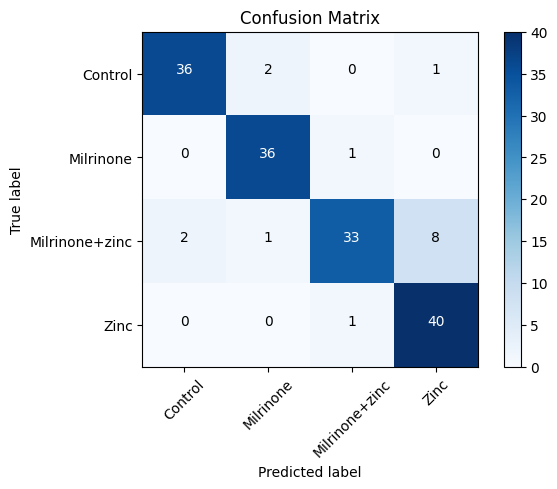

Accuracy Score: 0.9006211180124224
Precision Score: 0.9071820907808393
Recall Score: 0.9006211180124224
F1 Score: 0.8989074668435425
Classification Report:
                precision    recall  f1-score   support

       Control       0.95      0.92      0.94        39
     Milrinone       0.92      0.97      0.95        37
Milrinone+zinc       0.94      0.75      0.84        44
          Zinc       0.82      0.98      0.89        41

      accuracy                           0.90       161
     macro avg       0.91      0.91      0.90       161
  weighted avg       0.91      0.90      0.90       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.9006211180124224
Precision: 0.9074072543997356
Recall: 0.905414

train: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_3\train... 4174 images, 0 corrupt: 100%|██████████| 4174/417
val: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_3\val... 314 images, 0 corrupt: 100%|██████████| 314/314 [00:0


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 82 weight(decay=0.0), 83 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\train9
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 28.24it/s]

                   all      0.611          1


...

      30/30      1.58G     0.3361         14        224: 100%|██████████| 261/261 [00:33<00:00,  7.71it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 21.06it/s]

                   all      0.854          1



30 epochs completed in 0.324 hours.
Optimizer stripped from runs\classify\train9\weights\last.pt, 25.9MB
Optimizer stripped from runs\classify\train9\weights\best.pt, 25.9MB

Validating runs\classify\train9\weights\best.pt...
Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11l-cls summary (fused): 227 layers, 12,823,556 parameters, 0 gradients, 49.3 GFLOPs
train: C:\Users\conso\Desktop\qq\Mcells\Completed_3\train... found 4174 images in 4 classes  
val: C:\Users\conso\Desktop\qq\Mcells\Completed_3\val... found 314 images in 4 classes  
test: C:\Users\conso\Desktop\qq\Mcells\Completed_3\test... found 161 images in 4 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 18.44it/s]


                   all       0.86          1
Speed: 0.2ms preprocess, 1.4ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train9
-------------------------------
 Yolov11 L


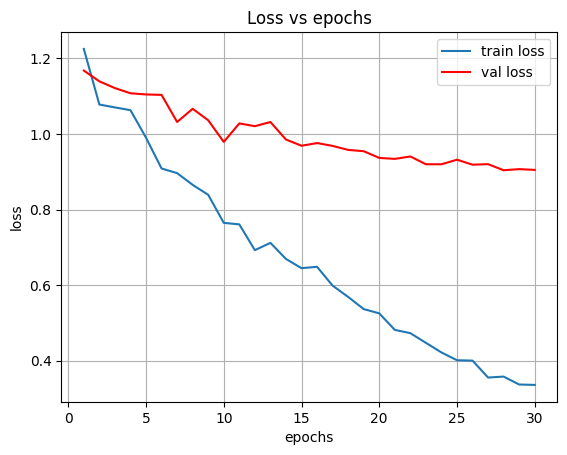

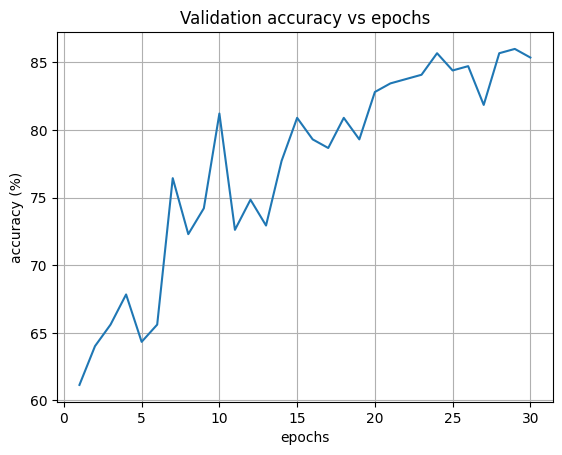

Load Best Model
Get the images from test directory for prediction

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 15.03.22 -02_1_0.jpg: 224x224 Control 0.98, Zinc 0.02, Milrinone 0.00, Milrinone+zinc 0.00, 31.5ms
Speed: 15.7ms preprocess, 31.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9780514240264893, 0.0044683534651994705, 6.184784433571622e-05, 0.017418449744582176]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 15.03.22 -03_1_0.jpg: 224x224 Zinc 0.52, Control 0.48, Milrinone 0.00, Milrinone+zinc 0.00, 33.0ms
Speed: 4.2ms preprocess, 33.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.4774114191532135, 0.0011351058492437005, 0.0010755168041214347, 0.5203779935836792]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\

Speed: 6.9ms preprocess, 15.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.0, 1.956212525300316e-09, 1.1706795532973047e-09, 2.9644331434042215e-10]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.05.22 D004-02_1_2.jpg: 224x224 Control 1.00, Milrinone 0.00, Zinc 0.00, Milrinone+zinc 0.00, 18.4ms
Speed: 5.2ms preprocess, 18.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9995900988578796, 0.00019910981063731015, 8.896210783859715e-05, 0.00012183103535789996]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.05.22 D004-02_2_1.jpg: 224x224 Control 0.94, Milrinone 0.06, Milrinone+zinc 0.00, Zinc 0.00, 18.4ms
Speed: 4.9ms preprocess, 18.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Mil

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-07_2_2.jpg: 224x224 Control 0.97, Milrinone+zinc 0.03, Zinc 0.00, Milrinone 0.00, 19.0ms
Speed: 5.0ms preprocess, 19.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.966903030872345, 0.0001524998078821227, 0.03125723823904991, 0.0016872240230441093]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22_0_1.jpg: 224x224 Control 0.85, Zinc 0.12, Milrinone 0.03, Milrinone+zinc 0.01, 20.4ms
Speed: 4.1ms preprocess, 20.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8502469062805176, 0.02500011958181858, 0.006606312934309244, 0.11814672499895096]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100  10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Mil

Speed: 4.1ms preprocess, 19.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.01792048290371895, 0.9649925827980042, 0.014553355984389782, 0.0025336050894111395]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_0_2.jpg: 224x224 Milrinone 0.51, Zinc 0.47, Control 0.02, Milrinone+zinc 0.00, 19.7ms
Speed: 4.1ms preprocess, 19.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.015664884820580482, 0.5067532658576965, 0.002631781855598092, 0.47495007514953613]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_2_2.jpg: 224x224 Milrinone 0.57, Zinc 0.37, Control 0.06, Milrinone+zinc 0.00, 19.8ms
Speed: 4.5ms preprocess, 19.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 

Speed: 4.1ms preprocess, 19.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[8.914556383388117e-05, 0.758633553981781, 0.24076424539089203, 0.0005130677600391209]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Zinc 0.00, Control 0.00, 18.7ms
Speed: 5.4ms preprocess, 18.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.0230662155663595e-05, 0.9952378273010254, 0.004558017011731863, 0.00019382168829906732]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_2_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 19.5ms
Speed: 5.1ms preprocess, 19.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0:

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_1.jpg: 224x224 Zinc 1.00, Milrinone+zinc 0.00, Control 0.00, Milrinone 0.00, 21.7ms
Speed: 4.3ms preprocess, 21.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[5.0769672270689625e-06, 1.0262178875564132e-06, 0.00288370531052351, 0.9971101880073547]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_2_0.jpg: 224x224 Milrinone+zinc 0.99, Control 0.00, Zinc 0.00, Milrinone 0.00, 43.8ms
Speed: 11.2ms preprocess, 43.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.004910469055175781, 1.72167062828521e-07, 0.9949051141738892, 0.00018428717157803476]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zi

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.23815622925758362, 0.0027979821898043156, 0.6792211532592773, 0.07982461899518967]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-05_1_1.jpg: 224x224 Zinc 0.98, Milrinone+zinc 0.01, Control 0.01, Milrinone 0.00, 18.4ms
Speed: 3.7ms preprocess, 18.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.006170301232486963, 0.00026716486900113523, 0.012589569203555584, 0.9809728860855103]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Milrinone 0.00, Zinc 0.00, 17.5ms
Speed: 5.5ms preprocess, 17.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00011488138989079744, 0.012354915030300617, 1.2307185670579202e-07, 0.9875301122665405]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_2_1.jpg: 224x224 Zinc 1.00, Milrinone 0.00, Control 0.00, Milrinone+zinc 0.00, 18.8ms
Speed: 4.2ms preprocess, 18.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.489368054943043e-06, 6.69196160743013e-05, 8.49071124520151e-09, 0.999929666519165]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -03_1_0.jpg: 224x224 Zinc 0.68, Milrinone 0.31, Control 0.01, Milrinone+zinc 0.00, 20.7ms
Speed: 3.2ms preprocess, 20.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.006033313926309347, 0.3140687346458435, 1.7559292246005498

Speed: 4.0ms preprocess, 20.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0005570685607381165, 0.00010790165833896026, 0.08552738279104233, 0.9138076305389404]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_1.jpg: 224x224 Zinc 0.95, Milrinone+zinc 0.05, Milrinone 0.00, Control 0.00, 20.1ms
Speed: 4.9ms preprocess, 20.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.2917541286915366e-07, 1.2114196579204872e-05, 0.04587540030479431, 0.9541122317314148]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_2.jpg: 224x224 Zinc 0.99, Milrinone+zinc 0.01, Milrinone 0.00, Control 0.00, 20.3ms
Speed: 4.0ms preprocess, 20.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milri

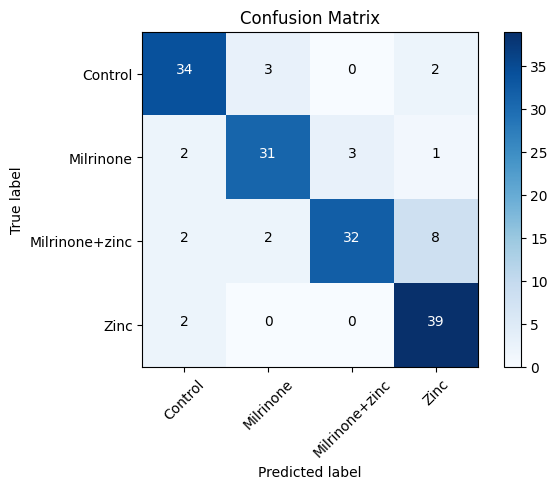

Accuracy Score: 0.84472049689441
Precision Score: 0.8522961648427487
Recall Score: 0.84472049689441
F1 Score: 0.8433708357175244
Classification Report:
                precision    recall  f1-score   support

       Control       0.85      0.87      0.86        39
     Milrinone       0.86      0.84      0.85        37
Milrinone+zinc       0.91      0.73      0.81        44
          Zinc       0.78      0.95      0.86        41

      accuracy                           0.84       161
     macro avg       0.85      0.85      0.84       161
  weighted avg       0.85      0.84      0.84       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.84472049689441
Precision: 0.8513492063492063
Recall: 0.847031237275

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-04_2_0.jpg: 224x224 Control 0.99, Milrinone 0.01, Zinc 0.00, Milrinone+zinc 0.00, 13.4ms
Speed: 3.0ms preprocess, 13.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9892921447753906, 0.01029718853533268, 1.6550822692806832e-05, 0.00039416240178979933]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-05_0_2.jpg: 224x224 Control 0.99, Milrinone 0.01, Zinc 0.00, Milrinone+zinc 0.00, 13.6ms
Speed: 3.3ms preprocess, 13.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9905744194984436, 0.005795081611722708, 7.430103869410232e-05, 0.003556251060217619]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-05_2_2.jpg: 

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9985305070877075, 3.4221946521029167e-07, 0.0014605055330321193, 8.529222213837784e-06]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-05_2_0.jpg: 224x224 Control 0.99, Zinc 0.01, Milrinone+zinc 0.00, Milrinone 0.00, 12.8ms
Speed: 3.8ms preprocess, 12.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9947026371955872, 7.257885044964496e-06, 0.00028321228455752134, 0.005006876308470964]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-07_1_2.jpg: 224x224 Control 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Zinc 0.00, 13.3ms
Speed: 5.6ms preprocess, 13.3ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9967604279518127, 0.00018048446509055793, 0.003050194

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_0.jpg: 224x224 Milrinone 1.00, Zinc 0.00, Milrinone+zinc 0.00, Control 0.00, 15.7ms
Speed: 0.0ms preprocess, 15.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[8.002629328984767e-06, 0.9998314380645752, 1.4053492122911848e-05, 0.000146428617881611]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_1.jpg: 224x224 Control 0.83, Milrinone 0.10, Zinc 0.05, Milrinone+zinc 0.02, 15.6ms
Speed: 0.0ms preprocess, 15.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8328976631164551, 0.10021897405385971, 0.019470123574137688, 0.047413263469934464]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_0.jpg: 224x224 Milrinone 1.00, Control 0.00, Zinc 0.00, Milrinone+zinc 0.00, 15.4ms
Speed: 0.7ms preprocess, 15.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.6177869838429615e-05, 0.9999701976776123, 5.25882614965667e-06, 8.328090189024806e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_2.jpg: 224x224 Milrinone 1.00, Control 0.00, Zinc 0.00, Milrinone+zinc 0.00, 13.7ms
Speed: 3.0ms preprocess, 13.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00010636930528562516, 0.9997839331626892, 4.3326595914550126e-05, 6.635657337028533e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.0

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[4.685611202148721e-06, 1.689909004198853e-05, 0.02883647382259369, 0.9711419939994812]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_0_2.jpg: 224x224 Zinc 0.86, Milrinone+zinc 0.14, Milrinone 0.00, Control 0.00, 12.6ms
Speed: 3.9ms preprocess, 12.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.94054678104294e-06, 2.8213039513502736e-06, 0.13524115085601807, 0.8647541403770447]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Zinc 0.00, Milrinone 0.00, 14.1ms
Speed: 4.1ms preprocess, 14.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.279338413150981e-05,

Speed: 2.9ms preprocess, 12.7ms inference, 1.1ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.005787333007901907, 0.14291009306907654, 0.8496823310852051, 0.0016202419064939022]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_1_0.jpg: 224x224 Zinc 0.81, Control 0.11, Milrinone+zinc 0.08, Milrinone 0.00, 13.1ms
Speed: 4.6ms preprocess, 13.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.10596401244401932, 0.00022223021369427443, 0.08255913853645325, 0.811254620552063]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_2_2.jpg: 224x224 Milrinone+zinc 0.87, Control 0.08, Zinc 0.05, Milrinone 0.00, 12.6ms
Speed: 4.1ms preprocess, 12.6ms inference, 0.0ms postprocess pe

Speed: 3.1ms preprocess, 13.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[4.3714462663047016e-05, 0.0006506110657937825, 0.00061056949198246, 0.9986950755119324]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100  Zinc 100uM 25.03.22 D025_2_2.jpg: 224x224 Zinc 1.00, Milrinone 0.00, Milrinone+zinc 0.00, Control 0.00, 13.2ms
Speed: 3.6ms preprocess, 13.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.6445977457333356e-05, 0.0031976106110960245, 0.0013575181365013123, 0.9954084753990173]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_0_2.jpg: 224x224 Zinc 0.98, Milrinone 0.02, Control 0.00, Milrinone+zinc 0.00, 12.7ms
Speed: 4.1ms preprocess, 12.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milr

Speed: 3.0ms preprocess, 14.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[4.452121515896579e-08, 0.0005542419967241585, 0.00031947498791851103, 0.9991262555122375]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-03_0_0.jpg: 224x224 Zinc 0.91, Milrinone+zinc 0.09, Milrinone 0.00, Control 0.00, 14.6ms
Speed: 3.1ms preprocess, 14.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.480725573965174e-07, 1.0970959010592196e-05, 0.08634430170059204, 0.913644015789032]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-03_2_2.jpg: 224x224 Zinc 0.88, Milrinone+zinc 0.12, Control 0.00, Milrinone 0.00, 11.0ms
Speed: 4.2ms preprocess, 11.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milri

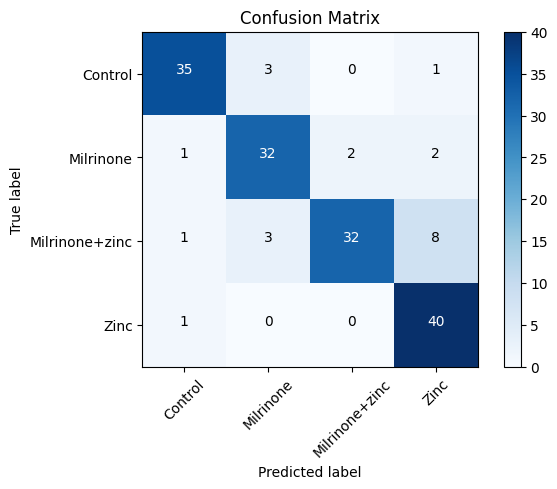

Accuracy Score: 0.8633540372670807
Precision Score: 0.8735874212385182
Recall Score: 0.8633540372670807
F1 Score: 0.8620038310775552
Classification Report:
                precision    recall  f1-score   support

       Control       0.92      0.90      0.91        39
     Milrinone       0.84      0.86      0.85        37
Milrinone+zinc       0.94      0.73      0.82        44
          Zinc       0.78      0.98      0.87        41

      accuracy                           0.86       161
     macro avg       0.87      0.87      0.86       161
  weighted avg       0.87      0.86      0.86       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8633540372670807
Precision: 0.8721620227038183
Recall: 0.866295

train: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_3\train... 4174 images, 0 corrupt: 100%|██████████| 4174/417
val: Scanning C:\Users\conso\Desktop\qq\Mcells\Completed_3\val... 314 images, 0 corrupt: 100%|██████████| 314/314 [00:0


optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.000714, momentum=0.9) with parameter groups 82 weight(decay=0.0), 83 weight(decay=0.0005), 83 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 224 train, 224 val
Using 8 dataloader workers
Logging results to runs\classify\train10
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 28.27it/s]

                   all      0.573          1


...

      30/30      2.61G     0.3812         14        224: 100%|██████████| 261/261 [00:38<00:00,  6.86it/s]
               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 19.30it/s]

                   all      0.834          1



30 epochs completed in 0.327 hours.
Optimizer stripped from runs\classify\train10\weights\last.pt, 57.0MB
Optimizer stripped from runs\classify\train10\weights\best.pt, 57.0MB

Validating runs\classify\train10\weights\best.pt...
Ultralytics 8.3.27  Python-3.10.13 torch-2.5.1+cu124 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
YOLO11x-cls summary (fused): 227 layers, 28,337,540 parameters, 0 gradients, 110.3 GFLOPs
train: C:\Users\conso\Desktop\qq\Mcells\Completed_3\train... found 4174 images in 4 classes  
val: C:\Users\conso\Desktop\qq\Mcells\Completed_3\val... found 314 images in 4 classes  
test: C:\Users\conso\Desktop\qq\Mcells\Completed_3\test... found 161 images in 4 classes  


               classes   top1_acc   top5_acc: 100%|██████████| 10/10 [00:00<00:00, 17.05it/s]


                   all      0.834          1
Speed: 0.1ms preprocess, 1.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to runs\classify\train10
-------------------------------
 Yolov11 X


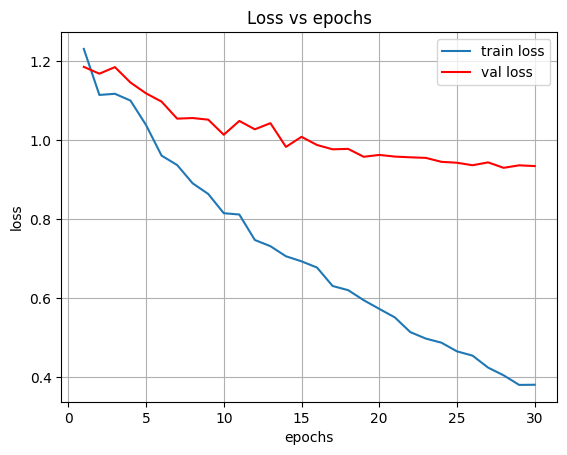

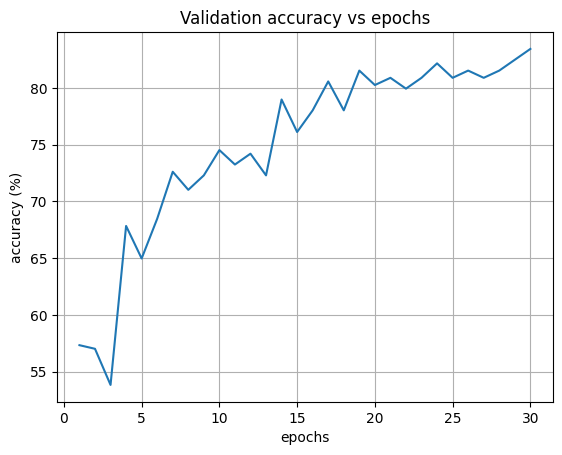

Load Best Model
Get the images from test directory for prediction

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 15.03.22 -02_1_0.jpg: 224x224 Control 0.54, Zinc 0.46, Milrinone+zinc 0.00, Milrinone 0.00, 16.8ms
Speed: 4.3ms preprocess, 16.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.5417012572288513, 0.00018064923642668873, 0.0001986607094295323, 0.4579194188117981]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 15.03.22 -03_1_0.jpg: 224x224 Control 0.91, Zinc 0.09, Milrinone+zinc 0.00, Milrinone 0.00, 23.6ms
Speed: 3.9ms preprocess, 23.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9122616648674011, 0.00032009760616347194, 0.0014688788214698434, 0.0859493836760521]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9999980926513672, 1.6525918908882886e-06, 9.846675652624981e-08, 9.211291995825377e-08]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.05.22 D004-02_1_2.jpg: 224x224 Control 1.00, Milrinone 0.00, Zinc 0.00, Milrinone+zinc 0.00, 20.1ms
Speed: 3.4ms preprocess, 20.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9995114803314209, 0.0002627634385135025, 5.184869678487303e-06, 0.00022046627418603748]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.05.22 D004-02_2_1.jpg: 224x224 Control 0.97, Milrinone 0.03, Milrinone+zinc 0.00, Zinc 0.00, 16.6ms
Speed: 5.0ms preprocess, 16.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9748213887214661, 0.025051819160580635, 

Speed: 5.0ms preprocess, 18.3ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9978461265563965, 7.362543328781612e-06, 0.0004561352252494544, 0.0016903565265238285]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22_0_1.jpg: 224x224 Control 0.57, Zinc 0.41, Milrinone+zinc 0.01, Milrinone 0.01, 19.6ms
Speed: 4.2ms preprocess, 19.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.5723854303359985, 0.008369984105229378, 0.009209837764501572, 0.41003474593162537]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100  10uM Milrinone D031 05.04.22-02_1_0.jpg: 224x224 Milrinone 0.92, Control 0.05, Zinc 0.02, Milrinone+zinc 0.00, 19.4ms
Speed: 4.6ms preprocess, 19.4ms inference, 1.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control',

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.016727501526474953, 0.9797869920730591, 0.0011262306943535805, 0.002359200967475772]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_0_2.jpg: 224x224 Milrinone 0.81, Zinc 0.12, Milrinone+zinc 0.06, Control 0.02, 19.0ms
Speed: 4.7ms preprocess, 19.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.019900508224964142, 0.8057496547698975, 0.05621364340186119, 0.11813614517450333]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006_2_2.jpg: 224x224 Zinc 0.41, Control 0.36, Milrinone 0.22, Milrinone+zinc 0.01, 18.7ms
Speed: 7.8ms preprocess, 18.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.36248451471328735, 0.22065806388854

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 23.8ms
Speed: 6.4ms preprocess, 23.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.06919194170041e-05, 0.9992081522941589, 0.0007673540385439992, 3.776578523684293e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_2_2.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 21.9ms
Speed: 4.1ms preprocess, 21.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00019607639114838094, 0.995790958404541, 0.004007604904472828, 5.3450876293936744e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100  Zinc+ 10uM Milr

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[7.4957629294658545e-06, 4.626290035503189e-07, 0.07068054378032684, 0.9293115139007568]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_2_0.jpg: 224x224 Milrinone+zinc 1.00, Zinc 0.00, Control 0.00, Milrinone 0.00, 18.1ms
Speed: 4.8ms preprocess, 18.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.000531076337210834, 1.851364504545927e-05, 0.9970961809158325, 0.00235427706502378]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-05_0_2.jpg: 224x224 Zinc 0.81, Milrinone+zinc 0.19, Milrinone 0.00, Control 0.00, 15.5ms
Speed: 4.9ms preprocess, 15.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[3.4515473089

Speed: 4.2ms preprocess, 18.0ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.02617677114903927, 0.013858072459697723, 0.31637731194496155, 0.6435878276824951]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_0.jpg: 224x224 Milrinone+zinc 1.00, Milrinone 0.00, Control 0.00, Zinc 0.00, 23.9ms
Speed: 9.6ms preprocess, 23.9ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0011876208009198308, 0.002592899138107896, 0.9959316849708557, 0.0002878074301406741]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-06_2_2.jpg: 224x224 Milrinone+zinc 0.99, Control 0.01, Milrinone 0.00, Zinc 0.00, 20.3ms
Speed: 5.5ms preprocess, 20.3ms inference, 0.0ms postprocess p

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.11932019889354706, 0.0784563347697258, 0.00011911640467587858, 0.8021043539047241]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -03_1_0.jpg: 224x224 Zinc 0.98, Milrinone 0.01, Control 0.01, Milrinone+zinc 0.00, 17.8ms
Speed: 4.4ms preprocess, 17.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.007810101378709078, 0.011118960566818714, 9.545765351504087e-06, 0.9810614585876465]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -04_2_2.jpg: 224x224 Zinc 0.74, Milrinone 0.25, Control 0.01, Milrinone+zinc 0.00, 37.4ms
Speed: 9.7ms preprocess, 37.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.01199561357498169, 0.2507767081260681, 0.000927845889236778, 0

Speed: 4.9ms preprocess, 18.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0003109346725977957, 0.002855864353477955, 0.656383216381073, 0.3404499590396881]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_2.jpg: 224x224 Zinc 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Control 0.00, 19.2ms
Speed: 4.5ms preprocess, 19.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.2679440547790364e-08, 2.074613576041884e-06, 0.0016411107499152422, 0.9983568787574768]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21_0_2.jpg: 224x224 Zinc 0.93, Milrinone 0.06, Milrinone+zinc 0.01, Control 0.00, 19.2ms
Speed: 3.8ms preprocess, 19.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'M

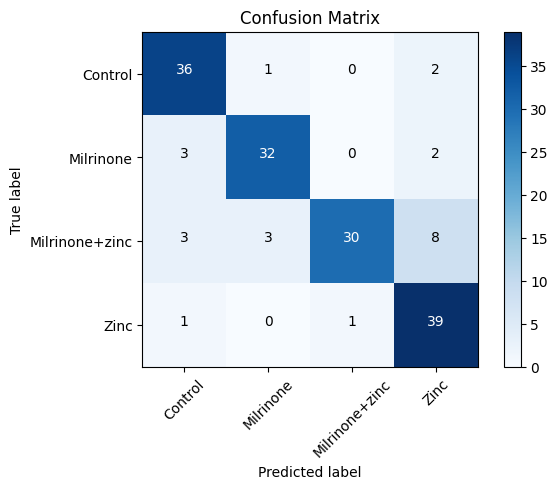

Accuracy Score: 0.8509316770186336
Precision Score: 0.8662958883065061
Recall Score: 0.8509316770186336
F1 Score: 0.8487150817927039
Classification Report:
                precision    recall  f1-score   support

       Control       0.84      0.92      0.88        39
     Milrinone       0.89      0.86      0.88        37
Milrinone+zinc       0.97      0.68      0.80        44
          Zinc       0.76      0.95      0.85        41

      accuracy                           0.85       161
     macro avg       0.86      0.86      0.85       161
  weighted avg       0.87      0.85      0.85       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8509316770186336
Precision: 0.8646365022628206
Recall: 0.855244

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-04_2_0.jpg: 224x224 Control 0.96, Milrinone 0.03, Zinc 0.00, Milrinone+zinc 0.00, 27.8ms
Speed: 9.5ms preprocess, 27.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9620823860168457, 0.03438902646303177, 0.00034169823629781604, 0.0031868997029960155]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-05_0_2.jpg: 224x224 Control 0.97, Zinc 0.02, Milrinone 0.01, Milrinone+zinc 0.00, 17.8ms
Speed: 5.2ms preprocess, 17.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9702969193458557, 0.009779023006558418, 0.0005761639913544059, 0.019347921013832092]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib 100 Control 25.03.22 D025-05_2_2.jpg: 2

{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9972992539405823, 1.4253811286835116e-07, 0.0021032998338341713, 0.000597295060288161]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-05_2_0.jpg: 224x224 Control 1.00, Zinc 0.00, Milrinone+zinc 0.00, Milrinone 0.00, 19.7ms
Speed: 5.1ms preprocess, 19.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.9969151020050049, 7.866235591791337e-07, 0.000276875653071329, 0.0028072604909539223]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Control\Fib100 Control 20.01.22-07_1_2.jpg: 224x224 Control 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Zinc 0.00, 19.4ms
Speed: 4.6ms preprocess, 19.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.999581515789032, 0.00011635168630164117, 0.000299554172

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_0.jpg: 224x224 Milrinone 1.00, Milrinone+zinc 0.00, Control 0.00, Zinc 0.00, 19.5ms
Speed: 3.3ms preprocess, 19.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0002645848144311458, 0.999362051486969, 0.00032791076228022575, 4.553959661279805e-05]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11.21 D006-05_1_1.jpg: 224x224 Control 0.82, Milrinone 0.10, Zinc 0.05, Milrinone+zinc 0.03, 19.7ms
Speed: 4.2ms preprocess, 19.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.8249135613441467, 0.10087527334690094, 0.02675567753612995, 0.0474555604159832]
Control

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib 100 10uM Mil Post 30.11

Speed: 4.0ms preprocess, 20.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.00011926711886189878, 0.9996104836463928, 0.00026930111926048994, 9.183171414406388e-07]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-03_2_2.jpg: 224x224 Milrinone 1.00, Control 0.00, Milrinone+zinc 0.00, Zinc 0.00, 22.1ms
Speed: 4.2ms preprocess, 22.1ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0006672031013295054, 0.9990010857582092, 0.00033024855656549335, 1.4285415090853348e-06]
Milrinone

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone\Fib100 10uM Milrinone 20.01.22-05_1_1.jpg: 224x224 Milrinone 0.99, Milrinone+zinc 0.01, Zinc 0.00, Control 0.00, 20.9ms
Speed: 4.0ms preprocess, 20.9ms inference, 0.9ms postprocess per image at shape (1, 3, 224, 22

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_0_2.jpg: 224x224 Zinc 0.82, Milrinone+zinc 0.18, Milrinone 0.00, Control 0.00, 20.6ms
Speed: 4.1ms preprocess, 20.6ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[6.3710817812534515e-06, 0.000131923719891347, 0.17831270396709442, 0.8215489387512207]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 10uM Mil+Zn Post 30.11.21 D006-04_1_0.jpg: 224x224 Milrinone+zinc 1.00, Control 0.00, Zinc 0.00, Milrinone 0.00, 19.6ms
Speed: 4.2ms preprocess, 19.6ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.001606726204045117, 1.997303479583934e-05, 0.998162567615509, 0.00021069021022412926]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_1_0.jpg: 224x224 Zinc 0.92, Control 0.07, Milrinone+zinc 0.01, Milrinone 0.00, 17.2ms
Speed: 5.4ms preprocess, 17.2ms inference, 0.2ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.07145912945270538, 4.4261407310841605e-05, 0.005217507481575012, 0.9232791662216187]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milrinone+zinc\Fib 100 Zinc+post 10uM Milrinone D006 06.04.22-03_2_2.jpg: 224x224 Milrinone+zinc 0.40, Control 0.32, Zinc 0.27, Milrinone 0.00, 16.5ms
Speed: 4.1ms preprocess, 16.5ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.32307660579681396, 0.002953251823782921, 0.4044589400291443, 0.2695111930370331]
Milrinone+zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Milr

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100  Zinc 100uM 25.03.22 D025_2_2.jpg: 224x224 Zinc 1.00, Milrinone+zinc 0.00, Milrinone 0.00, Control 0.00, 18.2ms
Speed: 4.8ms preprocess, 18.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[1.7271403294216725e-06, 0.00010155319614568725, 0.00038937877980060875, 0.9995074272155762]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_0_2.jpg: 224x224 Zinc 0.99, Milrinone 0.01, Control 0.00, Milrinone+zinc 0.00, 18.4ms
Speed: 7.9ms preprocess, 18.4ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.0003273172478657216, 0.00639101630076766, 3.179950454068603e-07, 0.993281364440918]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 100uM Zinc 15.03.22 -02_2_1.jpg: 224x224 Zinc 0

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-03_0_0.jpg: 224x224 Zinc 0.99, Milrinone+zinc 0.01, Milrinone 0.00, Control 0.00, 19.7ms
Speed: 4.2ms preprocess, 19.7ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[2.6580044831803207e-08, 0.00013771280646324158, 0.006636361591517925, 0.9932258725166321]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-03_2_2.jpg: 224x224 Zinc 0.51, Milrinone+zinc 0.46, Control 0.03, Milrinone 0.00, 18.8ms
Speed: 4.1ms preprocess, 18.8ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
{0: 'Control', 1: 'Milrinone', 2: 'Milrinone+zinc', 3: 'Zinc'}
[0.03351857140660286, 0.001900997362099588, 0.4585891366004944, 0.5059912800788879]
Zinc

image 1/1 C:\Users\conso\Desktop\qq\Mcells\Completed_3\test\Zinc\Fib 100 Zn2+ 19.01.21-05_1_1.jpg: 224x224 Milrinone+zinc 0.66, Zinc 0.34, Mi

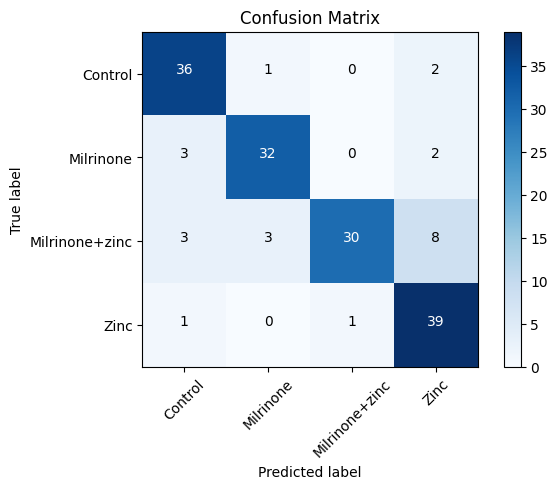

Accuracy Score: 0.8509316770186336
Precision Score: 0.8662958883065061
Recall Score: 0.8509316770186336
F1 Score: 0.8487150817927039
Classification Report:
                precision    recall  f1-score   support

       Control       0.84      0.92      0.88        39
     Milrinone       0.89      0.86      0.88        37
Milrinone+zinc       0.97      0.68      0.80        44
          Zinc       0.76      0.95      0.85        41

      accuracy                           0.85       161
     macro avg       0.86      0.86      0.85       161
  weighted avg       0.87      0.85      0.85       161

Confusion Matrix Plotted and ready for metrics evaluation
-------------------------------------------------------------------------------------------------------------------------------


-------------------------------------------------------------------------------------------------------------------------------


Accuracy: 0.8509316770186336
Precision: 0.8646365022628206
Recall: 0.855244

In [7]:
x = 6
names_model = 'Mcells-y11 with Augmentation '

data_folder = r'C:\Users\conso\Desktop\qq\Mcells\Completed_3'

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_3\test'

models = [YOLO('yolo11n-cls.pt'), YOLO('yolo11s-cls.pt'), YOLO('yolo11m-cls.pt'), YOLO('yolo11l-cls.pt'), YOLO('yolo11x-cls.pt')]
model_names = [' Yolov11 N', ' Yolov11 S', ' Yolov11 M', ' Yolov11 L', ' Yolov11 X']

paths = [fr"C:\Users\conso\Desktop\Yolo11\runs\classify\train{'' if i == 1 else i}\results.csv" for i in range(x, x+5)]

best_models = [fr"C:\Users\conso\Desktop\Yolo11\runs\classify\train{'' if i == 1 else i}\\weights\best.pt" for i in range(x, x+5)]
last_models = [fr"C:\Users\conso\Desktop\Yolo11\runs\classify\train{'' if i == 1 else i}\\weights\last.pt" for i in range(x, x+5)]

for mdel, model_name, path, best_model, last_model in zip(models, model_names, paths, best_models, last_models):
    model = mdel
    model.train(data= data_folder, epochs=30, imgsz=224) 

    print('-------------------------------')
    print(model_name)
    results_path = path

    name_model = names_model + best_model[-7:-3] +  model_name

    yolo_model_plot(results_path)


    # load a custom model
    print('Load Best Model')
    model = YOLO(best_model)

    # Get all the images in the test directory with the function
    actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

    # Plot the confusion matrix from the above
    conf_matrix = con_matrix_test(actual_image, predicted_image)

    # Get the test data metrics
    metrics_test(conf_matrix ,yolo_val_metrics = False)
    print('***********************************************************')

    # load a custom model
    print('Load Last Model')
    name_model = names_model + last_model[-7:-3] +  model_name
    model = YOLO(last_model)

    # Get all the images in the test directory with the function
    actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

    # Plot the confusion matrix from the above
    conf_matrix = con_matrix_test(actual_image, predicted_image)

    # Get the test data metrics
    metrics_test(conf_matrix ,yolo_val_metrics = False)
    print('***********************************************************') 

In [8]:
print(results)

[{'name_model': 'Mcells-y11 without Augmentation best Yolov11 N', 'Train Accuracy': 0.76433, 'Val Accuracy': 0.76433, 'Test Accuracy': 0.7391304347826086, 'Precision': 0.7393790849673203, 'Recall': 0.7390713137664358}, {'name_model': 'Mcells-y11 without Augmentation last Yolov11 N', 'Train Accuracy': 0.76433, 'Val Accuracy': 0.76433, 'Test Accuracy': 0.7763975155279503, 'Precision': 0.7769937844022512, 'Recall': 0.7769412662705346}, {'name_model': 'Mcells-y11 without Augmentation best Yolov11 S', 'Train Accuracy': 0.77389, 'Val Accuracy': 0.77389, 'Test Accuracy': 0.8385093167701864, 'Precision': 0.8466066919191919, 'Recall': 0.8391676577652187}, {'name_model': 'Mcells-y11 without Augmentation last Yolov11 S', 'Train Accuracy': 0.77389, 'Val Accuracy': 0.77389, 'Test Accuracy': 0.8074534161490683, 'Precision': 0.8153011204481793, 'Recall': 0.8083671574525233}, {'name_model': 'Mcells-y11 without Augmentation best Yolov11 M', 'Train Accuracy': 0.79618, 'Val Accuracy': 0.79618, 'Test Accu

In [11]:
df = pd.DataFrame(results)

df.to_csv('Mcellsv11.csv', index = False)

In [9]:
xxx

NameError: name 'xxx' is not defined

## TRAIN YOLOv11 S

In [ ]:
model = YOLO('yolov11s-cls.pt')  # load a pretrained model (recommended for training)

model.train(data= data_folder, epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 S') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train2\results.csv"

name_model = 'Mcells without Augmentation Best Yolov11 S'

yolo_model_plot(results_path)

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train2\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
name_model = 'Mcells without Augmentation Last Yolov11 S'
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train2\weights\last.pt")

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************') 

In [ ]:
print(results)

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train2\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [43, 0, 3, 5],
    [2, 49, 1, 0],
    [4, 1, 44, 4],
    [1, 0, 2, 41]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 

## TRAIN YOLOv11 M

In [ ]:
model = YOLO('yolov11m-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\Mcells\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 M') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train3\results.csv"

name_model = 'Mcells without Augmentation Best Yolov11 M'


yolo_model_plot(results_path)


# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train3\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')

name_model = 'Mcells without Augmentation Last Yolov11 M'
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train3\weights\last.pt")

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
print(results)

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train3\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

## TRAIN YOLOv11 Large

In [ ]:
model = YOLO('yolov11l-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\Mcells\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 L') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train4\results.csv"

name_model = 'Mcells without Augmentation Best Yolov11 L'


yolo_model_plot(results_path)

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train4\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train4\weights\last.pt")

name_model = 'Mcells without Augmentation Last Yolov11 L'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
print(results)

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train4\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [38, 1, 1, 3],
    [4, 49, 2, 1],
    [3, 0, 47, 2],
    [5, 0, 0, 44]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 

# TRAIN YOLOv11 - EXTRA 

In [ ]:
# load a pretrained model (recommended for training)
model = YOLO('yolov11x-cls.pt') 

# Train the model by passing in the completed_2 folder
model.train(data=r'C:\Users\conso\Desktop\qq\Mcells\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 X')
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train5\results.csv"

name_model = 'Mcells without Augmentation Best Yolov11 X'

yolo_model_plot(results_path)

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train5\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train5\weights\last.pt")


name_model = 'Mcells without Augmentation Last Yolov11 X'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
print(results)

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train5\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [44, 0, 3, 3],
    [2, 49, 0, 0],
    [1, 1, 44, 0],
    [3, 0, 3, 47]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 

# MCELLS WITH AUGMENTATION

## TRAIN YOLOv11 N

In [ ]:
model = YOLO('yolov11n-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\Mcells\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 N') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train6\results.csv"

yolo_model_plot(results_path)

name_model = 'Mcells with Augmentation Best Yolov11 N'


# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train6\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train6\weights\last.pt")

name_model = 'Mcells with Augmentation Last Yolov11 N'

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
print(results)

In [ ]:
import matplotlib.image as mpimg
# Load the image from file
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train6\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [46, 1, 3, 0],
    [2, 48, 0, 0],
    [5, 2, 41, 2],
    [5, 0, 1, 44]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False)

## TRAIN YOLOv11 S

In [ ]:
model = YOLO('yolov11s-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\Mcells\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 S') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train7\results.csv"

yolo_model_plot(results_path)

name_model = 'Mcells with Augmentation Best Yolov11 S'


# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train7\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train7\weights\last.pt")

name_model = 'Mcells with Augmentation Last Yolov11 S'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
print(results)

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train7\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [42, 1, 5, 9],
    [4, 48, 2, 1],
    [3, 0, 41, 1],
    [1, 1, 2, 39]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 

## TRAIN YOLOv11 M

In [ ]:
model = YOLO('yolov11m-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\Mcells\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 M') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train8\results.csv"

yolo_model_plot(results_path)

name_model = 'Mcells with Augmentation Best Yolov11 M'


# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train8\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
name_model = 'Mcells with Augmentation Last Yolov11 M'
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train8\weights\last.pt")

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train8\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [44, 1, 2, 5],
    [2, 46, 3, 0],
    [3, 3, 43, 1],
    [1, 0, 2, 44]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 

## TRAIN YOLOv11 Large

In [ ]:
model = YOLO('yolov11l-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\Mcells\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 L') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train9\results.csv"

name_model = 'Mcells with Augmentation Best Yolov11 L'


yolo_model_plot(results_path)

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train9\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')

name_model = 'Mcells with Augmentation Last Yolov11 L'
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train9\weights\last.pt")

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train9\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [66, 1, 4, 3],
    [2, 65, 8, 7],
    [2, 2, 63, 7],
    [5, 4, 11, 64]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 

# TRAIN YOLOv11 - EXTRA 

In [ ]:
# load a pretrained model (recommended for training)
model = YOLO('yolov11x-cls.pt') 

# Train the model by passing in the completed_2 folder
model.train(data=r'C:\Users\conso\Desktop\qq\Mcells\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 X')
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train10\results.csv"

yolo_model_plot(results_path)

name_model = 'Mcells with Augmentation Best Yolov11 X'

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train10\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\Mcells\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

name_model = 'Mcells with Augmentation Last Yolov11 X'
# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train10\weights\last.pt")


# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train10\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [45, 2, 5, 6],
    [2, 48, 3, 0],
    [2, 0, 40, 2],
    [1, 0, 2, 42]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 

In [ ]:
print(results)

In [ ]:
results_sorted = sorted(results, key= lambda x:x['Test Accuracy'] , reverse=True)
df = pd.DataFrame(results_sorted)


# Round all values in the DataFrame to two decimal places
df = df.round(2) 
df

In [ ]:
df.to_csv('Mcells.csv', index=False)

# CONTROL VS OTHERS WITHOUT AUGMENTATION

## TRAIN YOLOv11 n

In [ ]:
model = YOLO('yolov11n-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\CvO\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 N') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train11\results.csv"

yolo_model_plot(results_path)

name_model = 'Control vs Other  without Augmentation Best Yolov11 N'


# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train11\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train11\weights\last.pt")

name_model = 'Control vs Other  without Augmentation Last Yolov11 N'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
import matplotlib.image as mpimg
# Load the image from file
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train11\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
print(results)

In [ ]:
conf_matrix = [
    [153, 21],
    [22, 154]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False)

## TRAIN YOLOv11 S

In [ ]:
model = YOLO('yolov11s-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\CvO\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 S') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train12\results.csv"

yolo_model_plot(results_path)

name_model = 'Control vs Other  without Augmentation Best Yolov11 S'

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train12\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train12\weights\last.pt")

name_model = 'Control vs Other  without Augmentation Last Yolov11 S'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train12\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [155, 19],
    [20, 156]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False)

## TRAIN YOLOv11 M

In [ ]:
model = YOLO('yolov11m-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\CvO\Completed_2', epochs=30, imgsz=224)

In [ ]:
print('Yolov11 M') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train13\results.csv"

yolo_model_plot(results_path)

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train13\weights\best.pt")

name_model = 'Control vs Other  without Augmentation Best Yolov11 M'


# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train13\weights\last.pt")


name_model = 'Control vs Other  without Augmentation Last Yolov11 M'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train13\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [164, 19],
    [11, 156]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False)

## TRAIN YOLOv11 Large

In [ ]:
model = YOLO('yolov11l-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\CvO\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 L') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train14\results.csv"

yolo_model_plot(results_path)

name_model = 'Control vs Other  without Augmentation Best Yolov11 L'


# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train14\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train14\weights\last.pt")


name_model = 'Control vs Other  without Augmentation Last Yolov11 L'
# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train14\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  
# Display the image inline
plt.imshow(img)
plt.axis('off')  
plt.show() 

In [ ]:
conf_matrix = [
    [159, 16],
    [16, 159]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False)

# TRAIN YOLOv11 - EXTRA 

In [ ]:
# load a pretrained model (recommended for training)
model = YOLO('yolov11x-cls.pt') 

# Train the model by passing in the completed_2 folder
model.train(data=r'C:\Users\conso\Desktop\qq\CvO\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 X')
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train15\results.csv"

yolo_model_plot(results_path)

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train15\weights\best.pt")

name_model = 'Control vs Other  without Augmentation Best Yolov11 X'

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train15\weights\last.pt")

name_model = 'Control vs Other  without Augmentation Last Yolov11 X'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train15\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [157, 16],
    [18, 159]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False)

# MCELLS WITH AUGMENTATION

## TRAIN YOLOv11 N

In [ ]:
model = YOLO('yolov11n-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\CvO\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 N') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train16\results.csv"

yolo_model_plot(results_path)

name_model = 'Control vs Other  with Augmentation Best Yolov11 N'

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train16\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train16\weights\last.pt")

name_model = 'Control vs Other  with Augmentation Last Yolov11 N'

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
import matplotlib.image as mpimg
# Load the image from file
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train16\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [164, 30],
    [11, 145]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False)

## TRAIN YOLOv11 S

In [ ]:
model = YOLO('yolov11s-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\CvO\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 S') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train17\results.csv"

yolo_model_plot(results_path)

name_model = 'Control vs Other  with Augmentation Best Yolov11 S'

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train17\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train17\weights\last.pt")

name_model = 'Control vs Other  with Augmentation Last Yolov11 S'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train17\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [169, 26],
    [6, 149]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 

## TRAIN YOLOv11 M

In [ ]:
model = YOLO('yolov11m-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\CvO\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 M') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train18\results.csv"

yolo_model_plot(results_path)

name_model = 'Control vs Other  with Augmentation Best Yolov11 M'

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train18\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train18\weights\last.pt")

name_model = 'Control vs Other  with Augmentation Last Yolov11 M'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train18\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [160, 16],
    [15, 159]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 

## TRAIN YOLOv11 Large

In [ ]:
model = YOLO('yolov11l-cls.pt')  # load a pretrained model (recommended for training)

model.train(data=r'C:\Users\conso\Desktop\qq\CvO\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 L') 
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train19\results.csv"

yolo_model_plot(results_path)

name_model = 'Control vs Other  with Augmentation Best Yolov11 L'

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train19\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train19\weights\last.pt")

name_model = 'Control vs Other  with Augmentation Last Yolov11 L'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train19\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [161, 17],
    [14, 158]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 

# TRAIN YOLOv11 - EXTRA 

In [ ]:
# load a pretrained model (recommended for training)
model = YOLO('yolov11x-cls.pt') 

# Train the model by passing in the completed_2 folder
model.train(data=r'C:\Users\conso\Desktop\qq\CvO\Completed_2', epochs=30, imgsz=224) 

In [ ]:
print('Yolov11 X')
results_path = r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train20\results.csv"

yolo_model_plot(results_path)

name_model = 'Control vs Other  with Augmentation Best Yolov11 X'

# load a custom model
print('Load Best Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train20\weights\best.pt")

# Get test data directory
test_data_dir = r'C:\Users\conso\Desktop\qq\CvO\Completed_2\test'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

# load a custom model
print('Load Last Model')
model = YOLO(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train20\weights\last.pt")

name_model = 'Control vs Other  with Augmentation Last Yolov11 X'

# Get all the images in the test directory with the function
actual_image, predicted_image = get_test_images_full_path(test_data_dir) 

# Plot the confusion matrix from the above
conf_matrix = con_matrix_test(actual_image, predicted_image)

# Get the test data metrics
metrics_test(conf_matrix ,yolo_val_metrics = False)
print('***********************************************************')

In [ ]:
img = Image.open(r"C:\Users\conso\Desktop\Git Projects\Platelets -  YOLOv11\runs\classify\train20\confusion_matrix.png")

# Set the size of the plot
plt.figure(figsize=(12, 12))  # Adjust the size as needed
# Display the image inline
plt.imshow(img)
plt.axis('off')  # Turn off axis labels
plt.show() 

In [ ]:
conf_matrix = [
    [164, 21],
    [11, 154]
              ]

metrics_test(conf_matrix , yolo_val_metrics = False) 